# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of four synthetic data generation models:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## Data Loading and Setup


In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
air_quality = fetch_ucirepo(id=360) 
  
# data (as pandas dataframes) 
X = air_quality.data.features 
y = air_quality.data.targets 
  
# metadata 
print(air_quality.metadata) 
  
# variable information 
print(air_quality.variables) 

{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

In [2]:
import pandas as pd
import numpy as np

X = X.drop(columns=["Date", "Time"], errors="ignore")
data = X.copy()
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")
data = data.replace(-200, np.nan)
for col in data.columns:
    data[col] = data[col].fillna(data[col].median())
data = data.dropna().reset_index(drop=True)
target_col = "CO(GT)"

# Drop date/time/session/ID features before generator training (high cardinality).
_drop_feature_cols = [
    "Date", "Time", "date_time",
    "session_id", "Session ID", "Session_ID", "session",
    "X1 transaction date",
]
data = data.drop(columns=[c for c in _drop_feature_cols if c in data.columns], errors="ignore")

n_samples = min(1000, len(data))
data = data.sample(n=n_samples, random_state=42).reset_index(drop=True)

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")
    data[col] = data[col].fillna(data[col].median())


# Generating synthetic data

In [3]:
# Import SDV libraries

import warnings
import sdv
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)


from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# Number of synthetic rows to generate per model
n_samples = len(data)

# Define models in one place
models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

# Store outputs
synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(data)

    synthetic_data = model.sample(n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )
    quality_report = evaluate_quality(
        real_data= data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    diag_score = diagnostic_report.get_score()
    qual_score = quality_report.get_score()
    summary.append((name, diag_score, qual_score))

# Quick comparison table
summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

# Example: best model synthetic data
best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())

c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\single_table\base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\single_table\base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(



Training CTGAN...


c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Generating report ...

(1/2) Evaluating Data Validity: |██████████| 13/13 [00:00<00:00, 1719.41it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 173.42it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 458.43it/s]|
Column Shapes Score: 80.23%

(2/2) Evaluating Column Pair Trends: |██████████| 78/78 [00:00<00:00, 167.47it/s]|
Column Pair Trends Score: 64.65%

Overall Score (Average): 72.44%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 13/13 [00:00<00:00, 1667.05it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00,  6.18it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 522.62it/s]|
Column Shapes Score: 69.38%

(2/2) Evaluating Column Pa

,Model,Diagnostic Score,Quality Score
0,GaussianCopula,1.0,0.948563
1,TVAE,1.0,0.927111
2,CTGAN,1.0,0.724395
3,CopulaGAN,1.0,0.671844



Best model by quality score: GaussianCopula


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.7,1309.0,160.0,18.3,1253.0,354.0,541.0,139.0,1552.0,1550.0,8.4,62.2,0.9913
1,2.2,1066.0,193.0,9.2,943.0,225.0,815.0,129.0,1447.0,1338.0,13.9,54.3,0.6153
2,1.0,909.0,196.0,1.8,573.0,125.0,1169.0,106.0,1004.0,712.0,12.4,61.3,0.8164
3,2.5,1147.0,139.0,8.0,896.0,297.0,631.0,122.0,1633.0,1159.0,19.6,76.4,1.7147
4,3.4,967.0,159.0,12.8,1068.0,310.0,713.0,125.0,1549.0,1193.0,27.9,30.3,0.9238


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<?, ?it/s]|
Column Shapes Score: 80.23%

(2/2) Evaluating Column Pair Trends: |██████████| 78/78 [00:00<00:00, 425.80it/s]|
Column Pair Trends Score: 64.65%

Overall Score (Average): 72.44%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 875.74it/s]|
Column Shapes Score: 69.38%

(2/2) Evaluating Column Pair Trends: |██████████| 78/78 [00:00<00:00, 412.07it/s]|
Column Pair Trends Score: 64.98%

Overall Score (Average): 67.18%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 860.45it/s]|
Column Shapes Score: 90.16%

(2/2) Evaluating Column Pair Trends: |██████████| 78/78 [00:00<00:00, 357.32it/s]|
Column Pair Trends Score: 95.26%

Overall Score (Average): 92.71%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 995.78it/s]|
Column Shapes Score: 90.98%

(2/2) Evaluating Column Pair Trends: |█

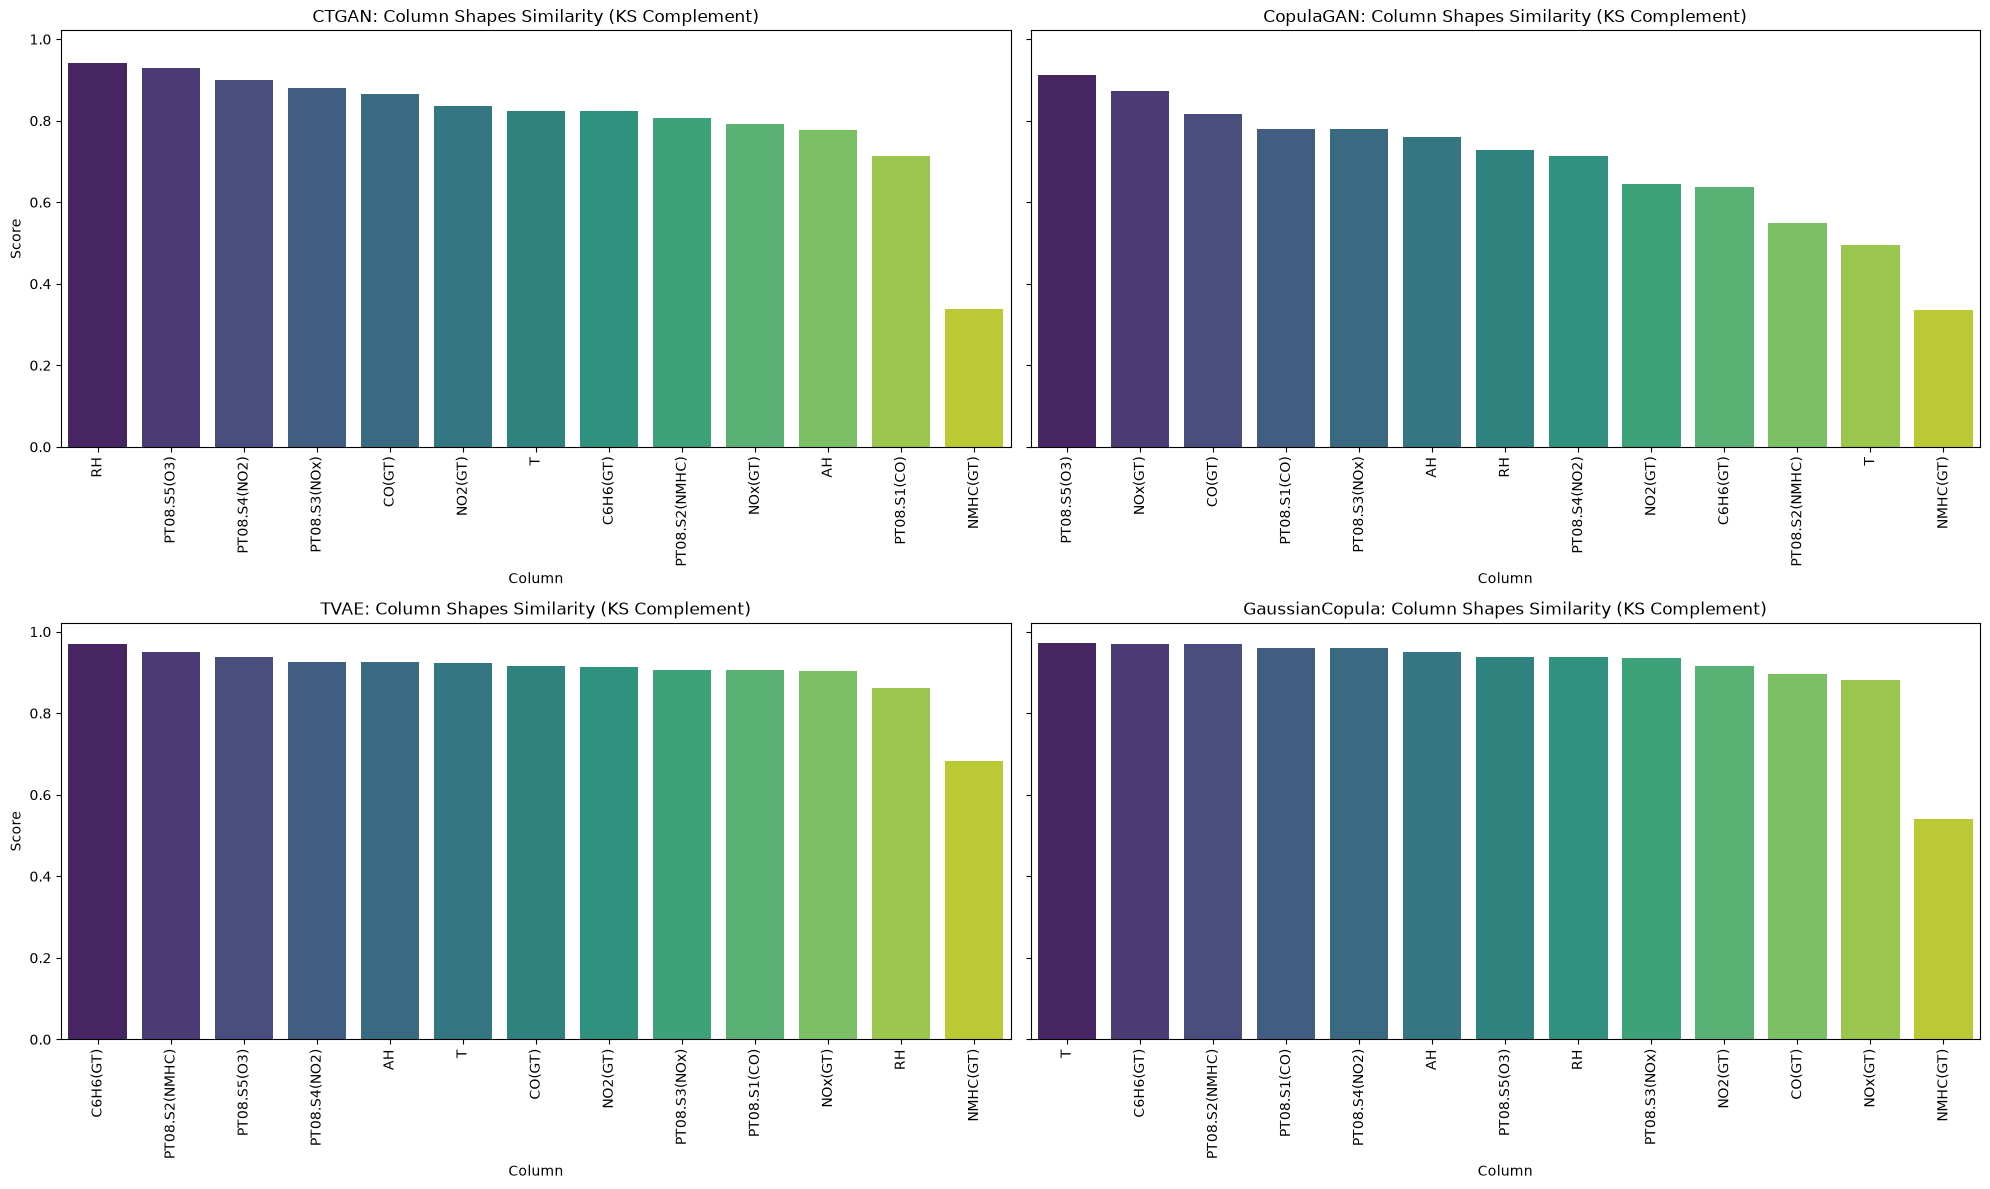

,Column,Metric,Score,Model
0,RH,KSComplement,0.941,CTGAN
1,PT08.S5(O3),KSComplement,0.930,CTGAN
2,PT08.S4(NO2),KSComplement,0.901,CTGAN
3,PT08.S3(NOx),KSComplement,0.879,CTGAN
4,CO(GT),KSComplement,0.865,CTGAN
5,NO2(GT),KSComplement,0.836,CTGAN
6,T,KSComplement,0.825,CTGAN
7,C6H6(GT),KSComplement,0.824,CTGAN
8,PT08.S2(NMHC),KSComplement,0.807,CTGAN
9,NOx(GT),KSComplement,0.793,CTGAN


In [4]:
import warnings
warnings.filterwarnings("ignore")

from sdv.evaluation.single_table import QualityReport
from sdv.metadata import SingleTableMetadata
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "CO(GT)"

real_eval = data.drop(columns=[target_col], errors="ignore").copy()

metadata_eval = SingleTableMetadata()
metadata_eval.detect_from_dataframe(real_eval)

column_shape_details = {}

for model_name in model_order:
    synth_eval = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore").copy()
    synth_eval = synth_eval[real_eval.columns]

    qr = QualityReport()
    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=metadata_eval.to_dict()
    )
    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column", y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity (KS Complement)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))


### 1.2. Jensen–Shannon divergence

In [5]:
import numpy as np
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")


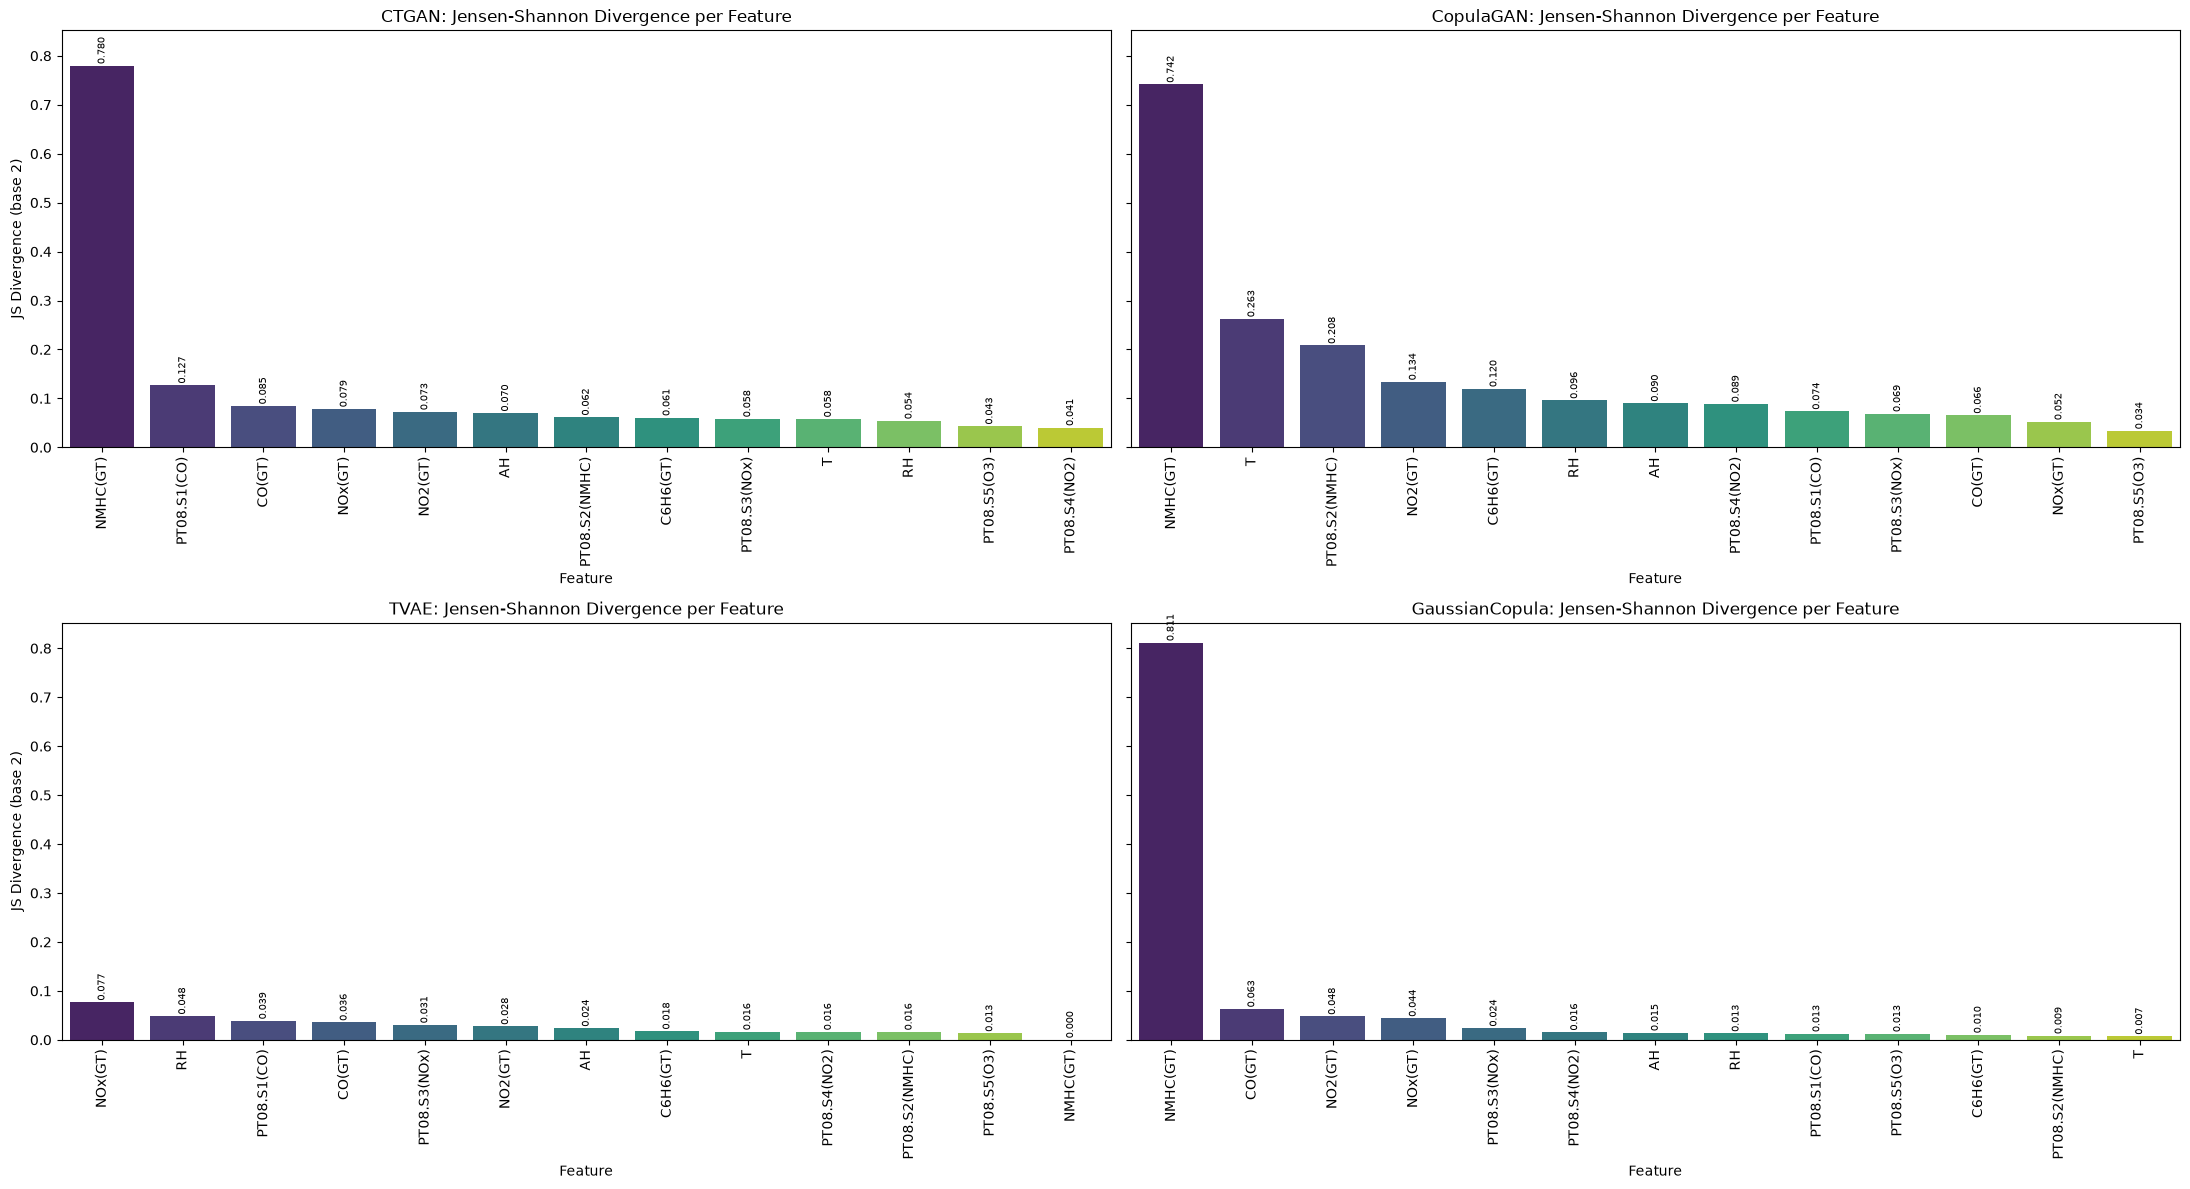

,Feature,JS_Divergence,Model
0,NMHC(GT),0.779892,CTGAN
1,PT08.S1(CO),0.127106,CTGAN
2,CO(GT),0.084614,CTGAN
3,NOx(GT),0.078746,CTGAN
4,NO2(GT),0.072724,CTGAN
5,AH,0.069913,CTGAN
6,PT08.S2(NMHC),0.061728,CTGAN
7,C6H6(GT),0.060879,CTGAN
8,PT08.S3(NOx),0.058235,CTGAN
9,T,0.058001,CTGAN


In [6]:
import matplotlib.pyplot as plt, numpy as np
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
js_results_by_model = {}

# Compute JS divergence for each model
for model_name in model_order:
    js_df = compute_js_divergence(
        data,
        synthetic_datasets[model_name],
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    js_results_by_model[model_name] = js_df

# Plot all 4 models in one figure (2x2)
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    # Add value labels
    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

# Optional: combined table for quick comparison
all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))

### 1.3 Wasserstein Distance



CTGAN - Wasserstein Distance:
CO(GT): 0.0188
PT08.S1(CO): 0.0976
NMHC(GT): 0.0114
C6H6(GT): 0.0384
PT08.S2(NMHC): 0.0862
NOx(GT): 0.0392
PT08.S3(NOx): 0.0500
NO2(GT): 0.0529
PT08.S4(NO2): 0.0376
PT08.S5(O3): 0.0376
T: 0.0750
RH: 0.0296
AH: 0.0920

CopulaGAN - Wasserstein Distance:
CO(GT): 0.0331
PT08.S1(CO): 0.0640
NMHC(GT): 0.0183
C6H6(GT): 0.1437
PT08.S2(NMHC): 0.2362
NOx(GT): 0.0171
PT08.S3(NOx): 0.0780
NO2(GT): 0.0868
PT08.S4(NO2): 0.0957
PT08.S5(O3): 0.0403
T: 0.2733
RH: 0.1371
AH: 0.0948

TVAE - Wasserstein Distance:
CO(GT): 0.0136
PT08.S1(CO): 0.0388
NMHC(GT): 0.0167
C6H6(GT): 0.0072
PT08.S2(NMHC): 0.0143
NOx(GT): 0.0297
PT08.S3(NOx): 0.0308
NO2(GT): 0.0175
PT08.S4(NO2): 0.0197
PT08.S5(O3): 0.0220
T: 0.0216
RH: 0.0539
AH: 0.0209

GaussianCopula - Wasserstein Distance:
CO(GT): 0.0159
PT08.S1(CO): 0.0085
NMHC(GT): 0.0409
C6H6(GT): 0.0067
PT08.S2(NMHC): 0.0072
NOx(GT): 0.0155
PT08.S3(NOx): 0.0172
NO2(GT): 0.0171
PT08.S4(NO2): 0.0102
PT08.S5(O3): 0.0116
T: 0.0062
RH: 0.0139
AH: 0.0

,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,GaussianCopula,0.014048,0.011792,0.040862
1,TVAE,0.023581,0.020857,0.053937
2,CTGAN,0.051268,0.039248,0.097593
3,CopulaGAN,0.101425,0.086848,0.273279


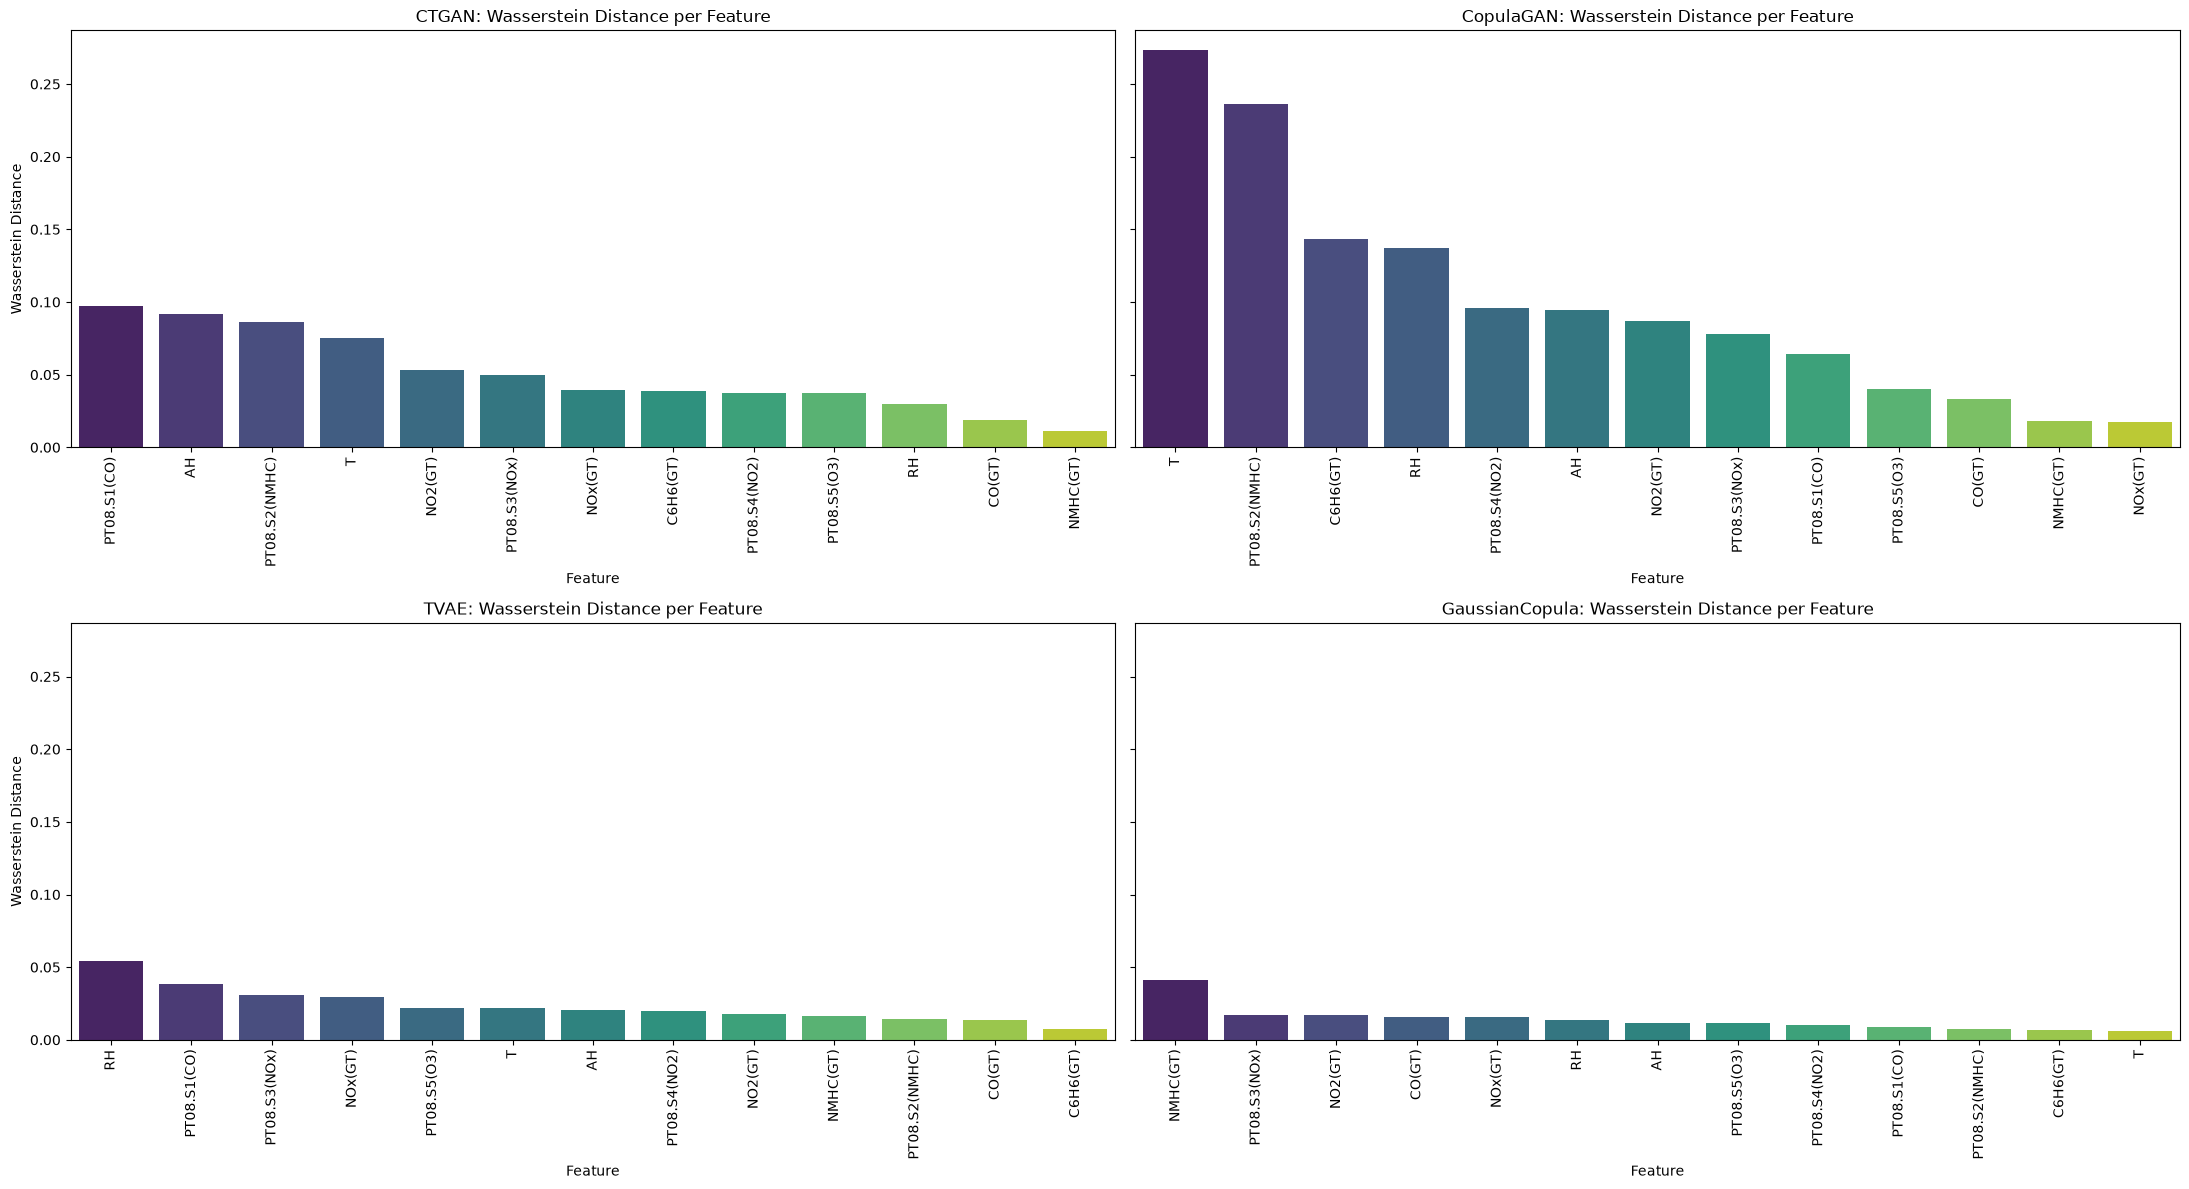

In [7]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes these already exist:
# - data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]

    # Ensure same column order as real data
    synth_df = synth_df[data.columns]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=synth_df.columns
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in data.columns:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, dist))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"]).sort_values(
        "Wasserstein_Distance", ascending=False
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(),
    })

# Summary table (lower is better)
summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

# Plot all 4 models in one figure
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance per Feature")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

### 1.4 Gower Distance

In [8]:
import numpy as np
import pandas as pd
import gower

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "CO(GT)"
id_col = "ID"
drop_cols = [c for c in [id_col, target_col] if c in data.columns]

X_real = data.drop(columns=drop_cols, errors="ignore").copy()

gower_results = []

for model_name in model_order:
    X_synth = synthetic_datasets[model_name].drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True).copy()
    Xs = X_synth[common_cols].reset_index(drop=True).copy()

    num_cols = Xr.select_dtypes(include=[np.number]).columns
    Xr[num_cols] = Xr[num_cols].astype(np.float64)
    Xs[num_cols] = Xs[num_cols].astype(np.float64)

    gower_real = 1.0 - gower.gower_matrix(Xr)
    gower_synth = 1.0 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = float(np.max(real_upper))
    avg_intra_real = float(np.mean(real_upper))
    max_intra_synth = float(np.max(synth_upper))
    avg_intra_synth = float(np.mean(synth_upper))

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1.0 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = float(np.max(cross_block))
    avg_cross = float(np.mean(cross_block))

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)



CTGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8245

Intra-set Similarity (Synthetic):
Max = 0.9569, Avg = 0.7943

Cross-set Similarity (Real vs Synthetic):
Max = 0.9580, Avg = 0.8044

CopulaGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8245

Intra-set Similarity (Synthetic):
Max = 0.9521, Avg = 0.7921

Cross-set Similarity (Real vs Synthetic):
Max = 0.9580, Avg = 0.7846

TVAE - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8245

Intra-set Similarity (Synthetic):
Max = 0.9700, Avg = 0.7903

Cross-set Similarity (Real vs Synthetic):
Max = 0.9802, Avg = 0.8167

GaussianCopula - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8245

Intra-set Similarity (Synthetic):
Max = 0.9796, Avg = 0.8030

Cross-set Similarity (Real vs Synthetic):
Max = 0.9807, Avg = 0.8225


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTGAN,1.0,0.824515,0.956920,0.794295,0.958050,0.804398
1,CopulaGAN,1.0,0.824515,0.952096,0.792138,0.958048,0.784604
2,TVAE,1.0,0.824515,0.969956,0.790281,0.980244,0.816653
3,GaussianCopula,1.0,0.824515,0.979572,0.802985,0.980652,0.822470


### 1.5 t-SNE Visualization


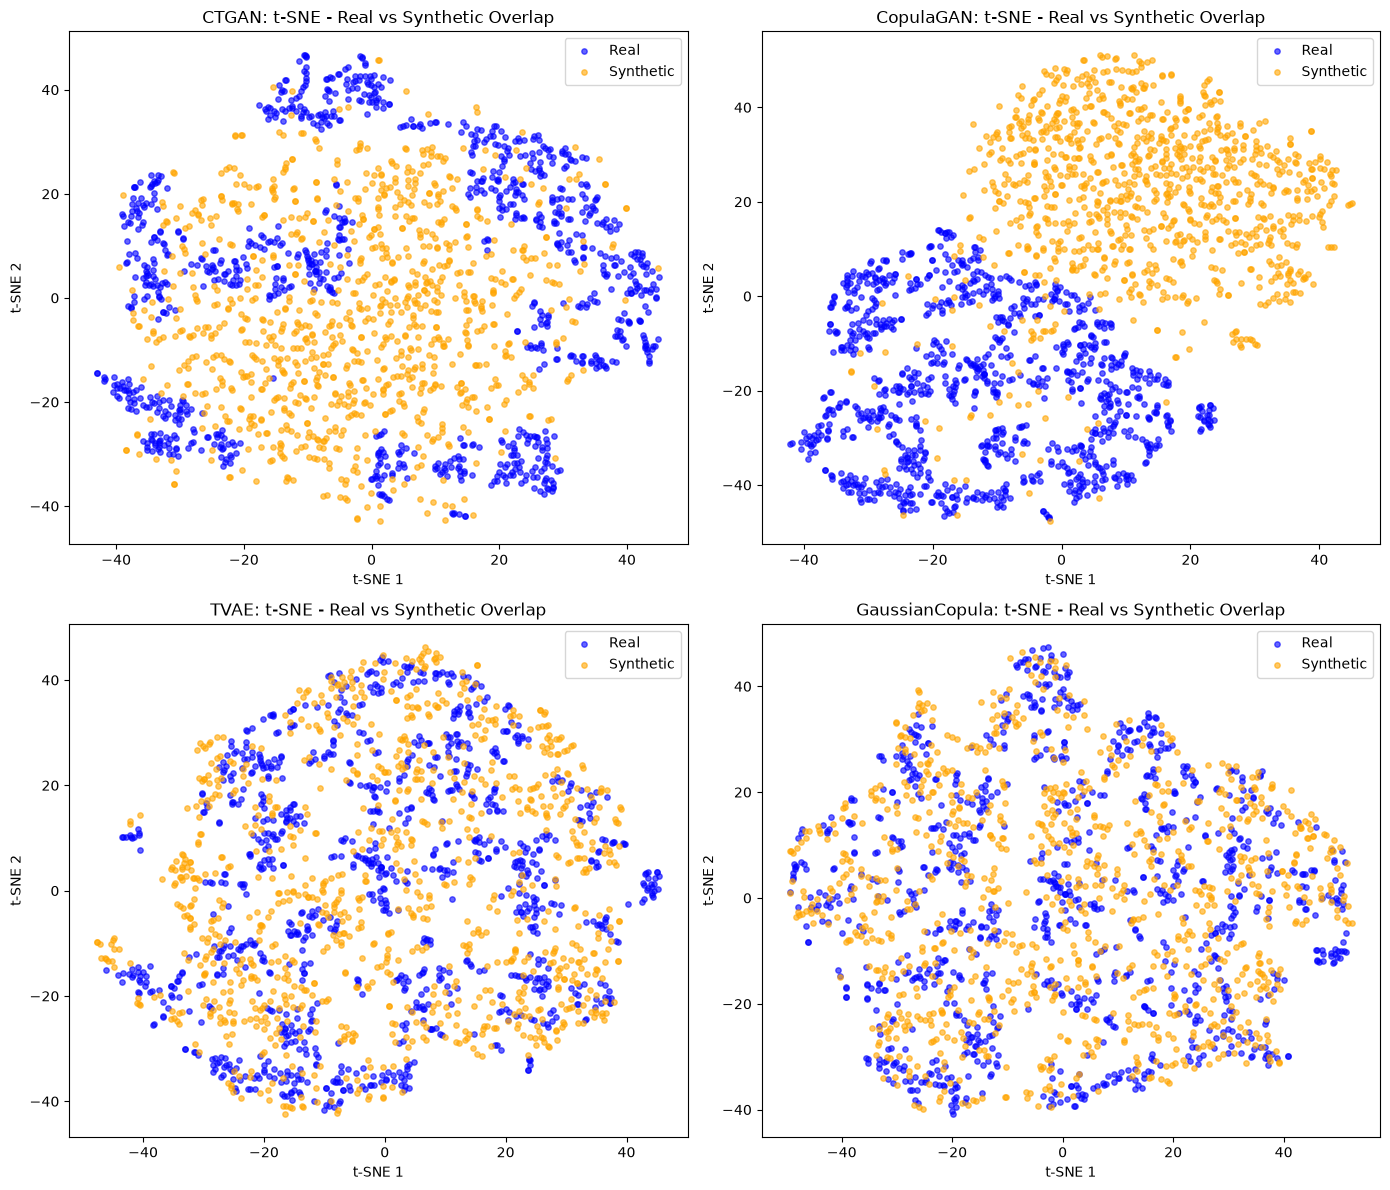

In [9]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes:
# - data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns
)

# Create 2x2 t-SNE plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name][data.columns]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=synth_df.columns
    )

    combined = np.vstack([real_scaled.values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

### 1.6 MMD (Maximum Mean Discrepancy)


In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

def _sample_rows(X, max_rows=2000, seed=42):
    if X.shape[0] <= max_rows:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=max_rows, replace=False)
    return X[idx]

def _median_gamma(X, Y):
    Z = np.vstack([X, Y])
    n = Z.shape[0]
    take = min(1200, n)
    idx = np.random.default_rng(42).choice(n, size=take, replace=False)
    Zs = Z[idx]
    d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
    vals = d2[np.triu_indices_from(d2, k=1)]
    med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
    return 1.0 / (2.0 * med)

def compute_mmd_rbf_safe(X, Y, gamma=None):
    if gamma is None:
        gamma = _median_gamma(X, Y)
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    return float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "CO(GT)"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
mmd_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].to_numpy(dtype=np.float64)
    X_synth = synth_features[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    Xr = _sample_rows(X_real_scaled, max_rows=2000, seed=42)
    Xs = _sample_rows(X_synth_scaled, max_rows=2000, seed=42)

    mmd_score = compute_mmd_rbf_safe(Xr, Xs, gamma=None)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})

    print(f"{model_name} - MMD score: {mmd_score:.6f}")

mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTGAN - MMD score: 0.043816
CopulaGAN - MMD score: 0.145107
TVAE - MMD score: 0.004921
GaussianCopula - MMD score: 0.001076

MMD comparison (lower is better):


,Model,MMD_Score
0,GaussianCopula,0.001076
1,TVAE,0.004921
2,CTGAN,0.043816
3,CopulaGAN,0.145107


### 1.7 Cosine Similarity


In [11]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "CO(GT)"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].copy()
    X_synth = synth_features[common_cols].copy()

    if "color" in X_real.columns:
        X_real["color"] = X_real["color"].astype("category").cat.codes
        X_synth["color"] = X_synth["color"].astype("category").cat.codes

    X_real = X_real.apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)
    X_synth = X_synth.apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = float(np.mean(cross_sim))
    max_sim = float(np.max(cross_sim))

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: 0.0059
Maximum cosine similarity: 0.9618

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: -0.0077
Maximum cosine similarity: 0.9468

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0073
Maximum cosine similarity: 0.9932

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: 0.0050
Maximum cosine similarity: 0.9921

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,TVAE,0.007304,0.993229
1,CTGAN,0.005920,0.961759
2,GaussianCopula,0.005010,0.992121
3,CopulaGAN,-0.007748,0.946774


### 1.8 Nearest Neighbours 


In [12]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "CO(GT)"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = float(np.mean(distances))
    min_nn_dist = float(np.min(distances))
    p5_nn_dist = float(np.percentile(distances, 5))

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 3.0742
Minimum NN Distance (Synthetic -> Real): 1.1344
5th Percentile NN Distance: 1.8176

CopulaGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 3.7731
Minimum NN Distance (Synthetic -> Real): 1.0035
5th Percentile NN Distance: 2.2388

TVAE - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.5166
Minimum NN Distance (Synthetic -> Real): 0.4878
5th Percentile NN Distance: 0.8945

GaussianCopula - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.2587
Minimum NN Distance (Synthetic -> Real): 0.3870
5th Percentile NN Distance: 0.7743

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,CopulaGAN,3.773073,1.003527,2.238810
1,CTGAN,3.074167,1.134360,1.817557
2,TVAE,1.516592,0.487754,0.894484
3,GaussianCopula,1.258695,0.386974,0.774345


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,9.509181,9.729608,19.097347
1,CopulaGAN,23.078899,15.842385,21.827939
2,TVAE,2.776245,2.082321,17.403283
3,GaussianCopula,0.998628,0.810867,3.906552


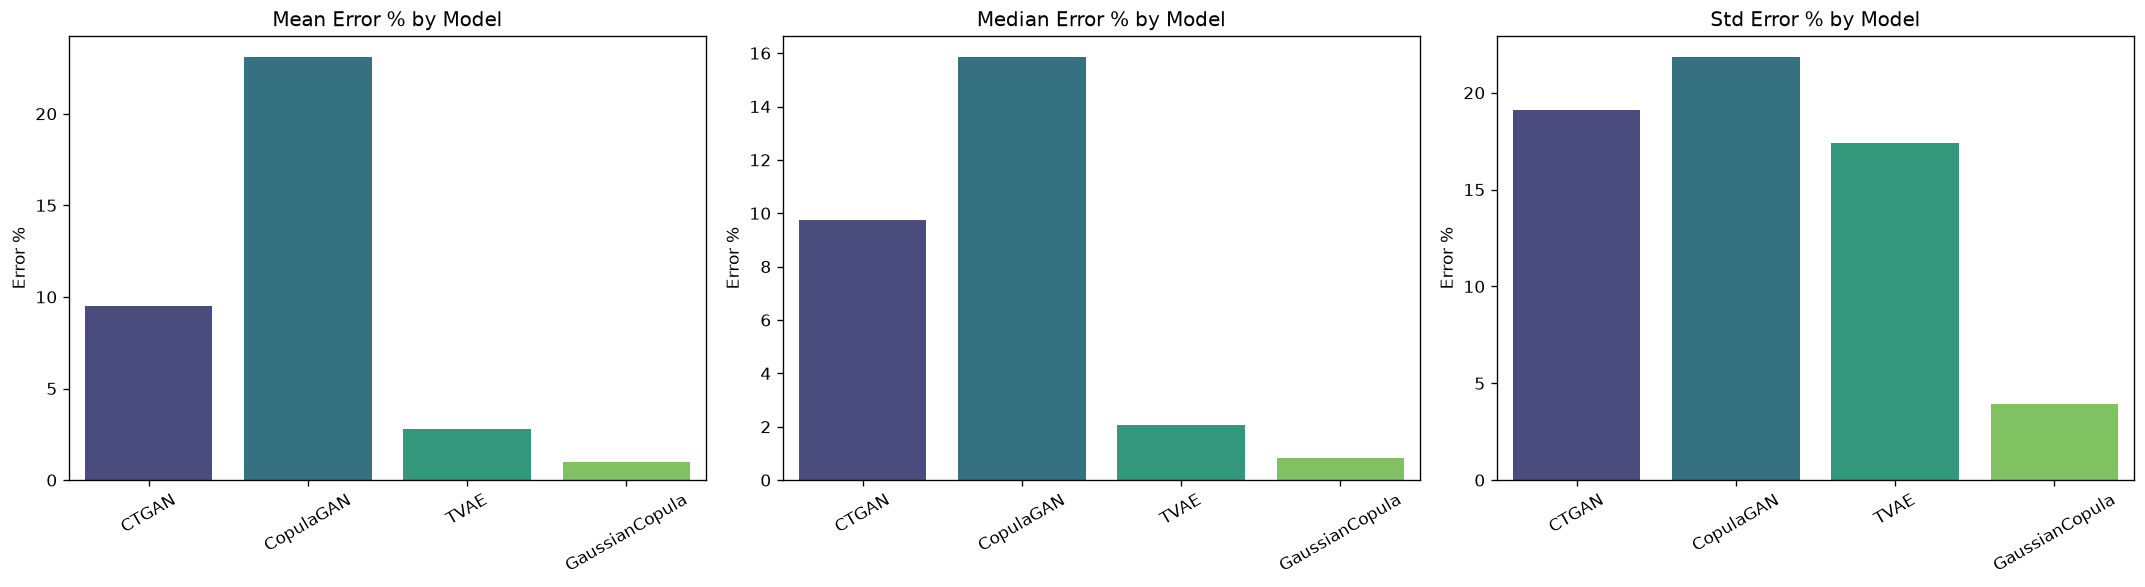

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
target_col = "CO(GT)"
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

drop_from_metrics = []
if "ID" in num_cols:
    drop_from_metrics.append("ID")
if target_col in num_cols:
    drop_from_metrics.append(target_col)

num_cols = [c for c in num_cols if c not in drop_from_metrics]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]
    synth_df = synth_df[_common]

    real_means = real_df[num_cols].astype(np.float64).mean()
    synth_means = synth_df[num_cols].astype(np.float64).mean()

    real_stds = real_df[num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100.0
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100.0

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


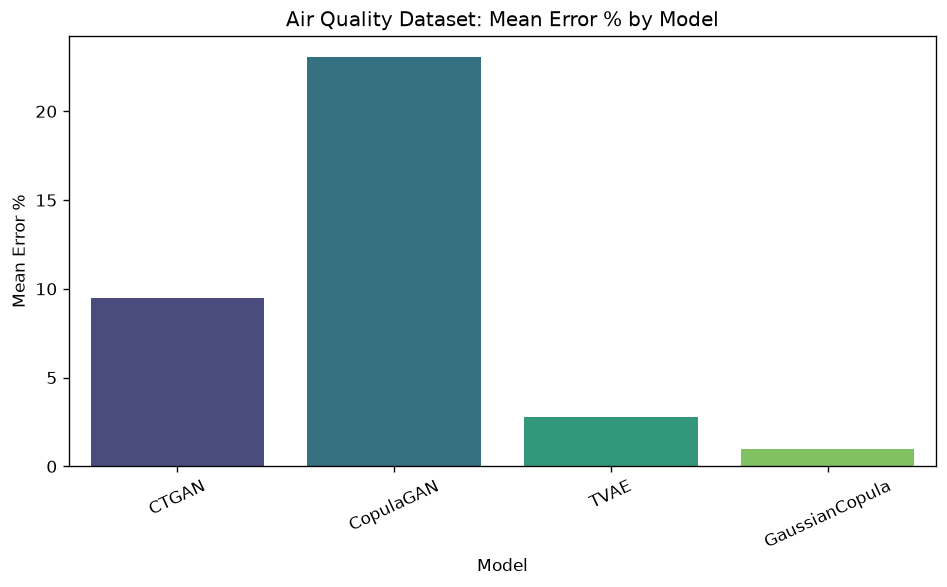

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("Air Quality Dataset: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

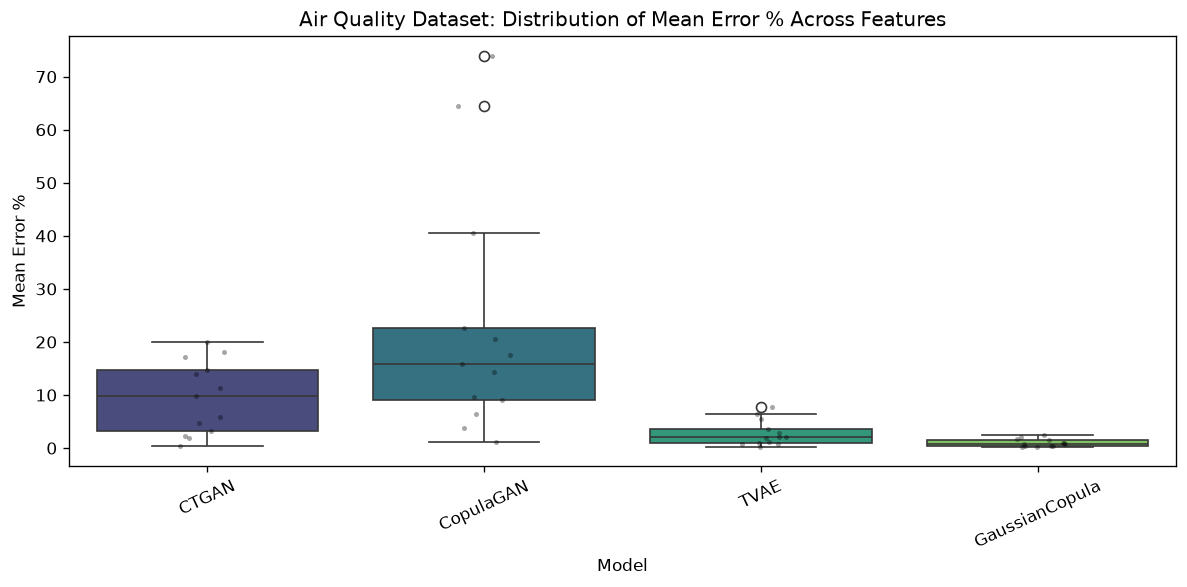

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Air Quality Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

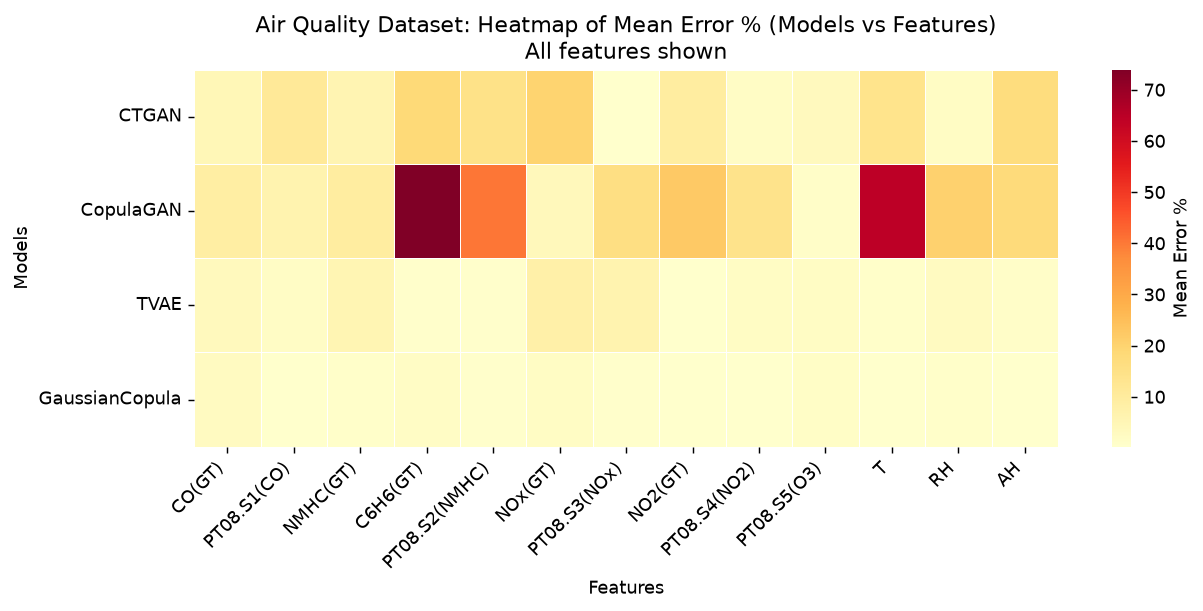

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Air Quality Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis


In [17]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

def bivariate_quality_regression(real_df, synth_df, target="CO(GT)", id_col=None, n_bins=5):
    num_cols = real_df.select_dtypes(include=["number"]).columns.tolist()
    exclude = {target, id_col} - {None}
    num_cols = [c for c in num_cols if c not in exclude]

    scaler = MinMaxScaler()
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()
    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({"var_a": a, "var_b": b, "delta_corr": abs(r_corr - s_corr)})

    results_target = []
    if target in real_scaled.columns and target in synth_scaled.columns:
        real_bins = pd.qcut(real_scaled[target], q=n_bins, duplicates="drop")
        synth_bins = pd.qcut(synth_scaled[target], q=n_bins, duplicates="drop")
        for col in num_cols:
            r_groups = [g[col].values for _, g in real_scaled.groupby(real_bins)]
            s_groups = [g[col].values for _, g in synth_scaled.groupby(synth_bins)]
            if len(r_groups) >= 2 and len(s_groups) >= 2:
                d_real = np.mean([stats.wasserstein_distance(r_groups[j], r_groups[j + 1]) for j in range(len(r_groups) - 1)])
                d_synth = np.mean([stats.wasserstein_distance(s_groups[j], s_groups[j + 1]) for j in range(len(s_groups) - 1)])
                results_target.append({"feature": col, "delta_wasserstein": abs(d_real - d_synth)})

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = (
        pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False)
        if results_target else pd.DataFrame(columns=["feature", "delta_wasserstein"])
    )
    return corr_df, target_df


In [18]:
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = data.copy()

target_col = "CO(GT)"
id_col = None

quality_fn = bivariate_quality_regression

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]
    synth_df = synth_df[_common]

    real_eval = real_df.drop(columns=[id_col], errors="ignore")
    synth_eval = synth_df.drop(columns=[id_col], errors="ignore")

    corr_results, target_results = quality_fn(
        real_df=real_eval,
        synth_df=synth_eval
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by {target_col} class:")
    display(target_results.head(10))
    print("=" * 60)

    corr_metric_col = next((c for c in ["delta_corr", "AbsDiff", "abs_diff", "Difference", "diff"] if c in corr_results.columns), None)
    target_metric_col = next((c for c in ["delta_wasserstein", "AbsDiff", "abs_diff", "Difference", "diff"] if c in target_results.columns), None)

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results[corr_metric_col].iloc[0] if corr_metric_col and not corr_results.empty else None,
        "MeanTop10CorrDiff": corr_results[corr_metric_col].head(10).mean() if corr_metric_col and not corr_results.empty else None,
        "TopTargetDiff": target_results[target_metric_col].iloc[0] if target_metric_col and not target_results.empty else None,
        "MeanTop10TargetDiff": target_results[target_metric_col].head(10).mean() if target_metric_col and not target_results.empty else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



CTGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
33,C6H6(GT),PT08.S2(NMHC),1.047007
19,PT08.S1(CO),PT08.S5(O3),0.926672
37,C6H6(GT),PT08.S4(NO2),0.884412
3,CO(GT),PT08.S2(NMHC),0.880631
13,PT08.S1(CO),C6H6(GT),0.870559
59,PT08.S3(NOx),PT08.S5(O3),0.869751
14,PT08.S1(CO),PT08.S2(NMHC),0.865197
38,C6H6(GT),PT08.S5(O3),0.861487
46,PT08.S2(NMHC),PT08.S5(O3),0.854930
4,CO(GT),NOx(GT),0.820502


CTGAN - Features that differ most by CO(GT) class:


,feature,delta_wasserstein



CopulaGAN - Largest differences in pairwise correlations:


...


GaussianCopula - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
32,NMHC(GT),AH,0.104403
25,NMHC(GT),NOx(GT),0.095480
51,NOx(GT),NO2(GT),0.083583
30,NMHC(GT),T,0.069239
12,PT08.S1(CO),NMHC(GT),0.066721
17,PT08.S1(CO),NO2(GT),0.058189
36,C6H6(GT),NO2(GT),0.055967
37,C6H6(GT),PT08.S4(NO2),0.049398
18,PT08.S1(CO),PT08.S4(NO2),0.044638
66,NO2(GT),RH,0.043518


GaussianCopula - Features that differ most by CO(GT) class:


,feature,delta_wasserstein


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTGAN,1.047007,0.888115,None,None
1,CopulaGAN,0.974993,0.844143,None,None
2,TVAE,0.281607,0.183322,None,None
3,GaussianCopula,0.104403,0.067114,None,None


### 3 Multivariate Analysis


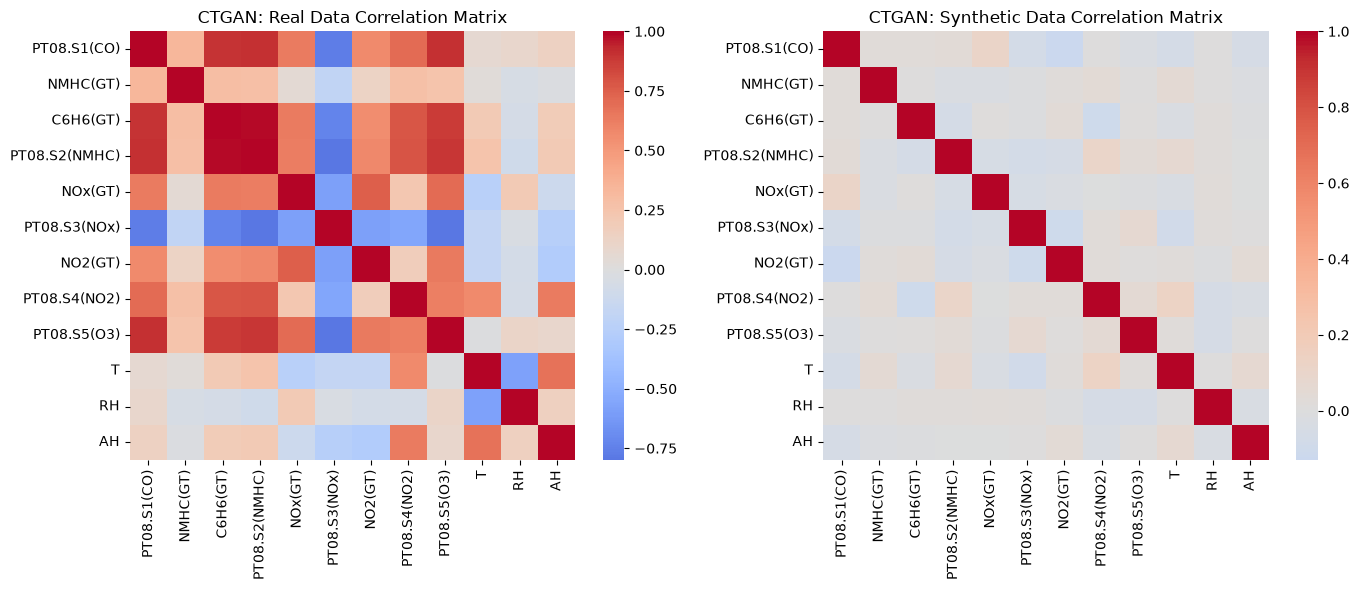

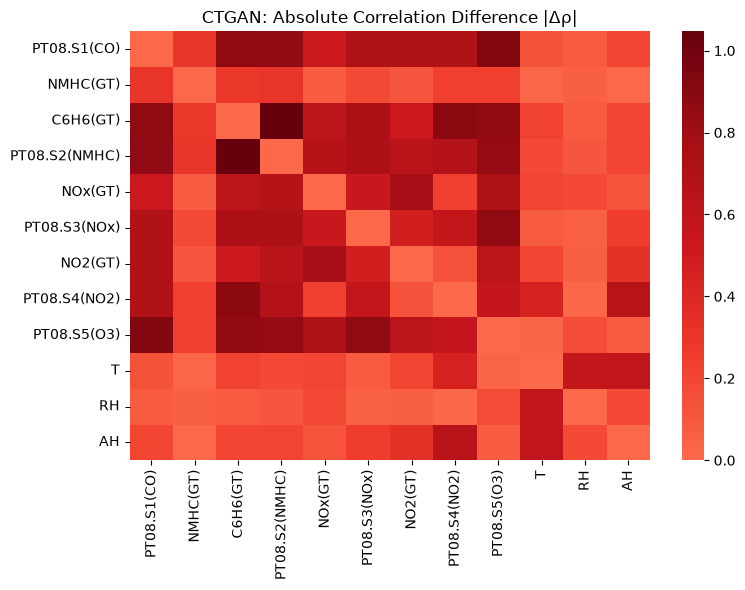

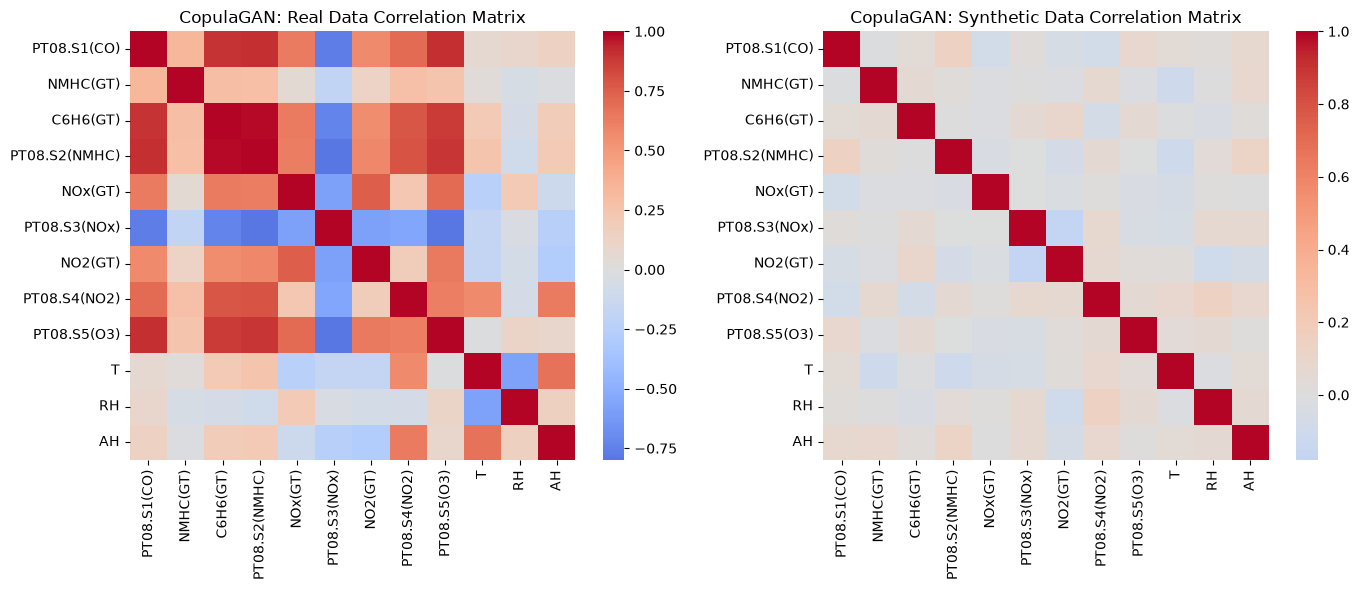

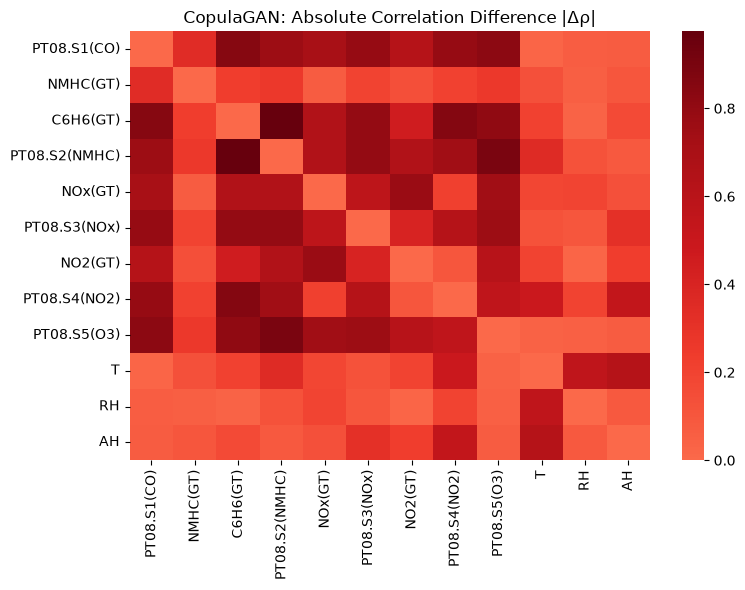

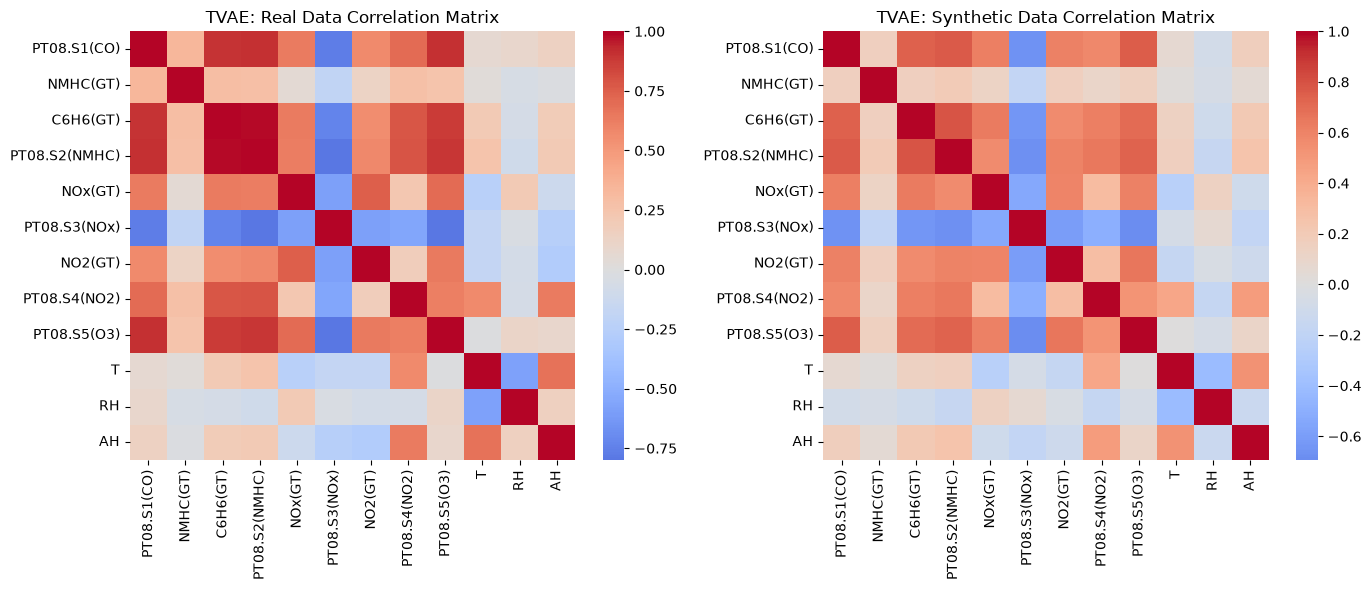

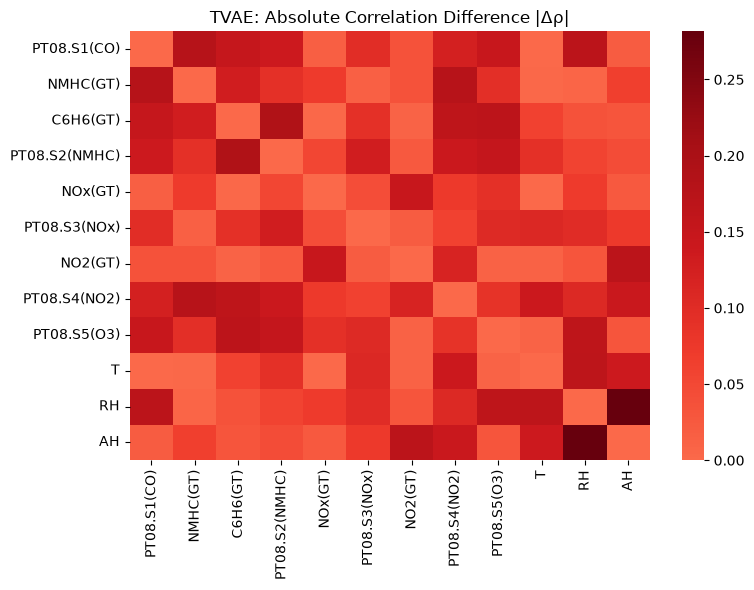

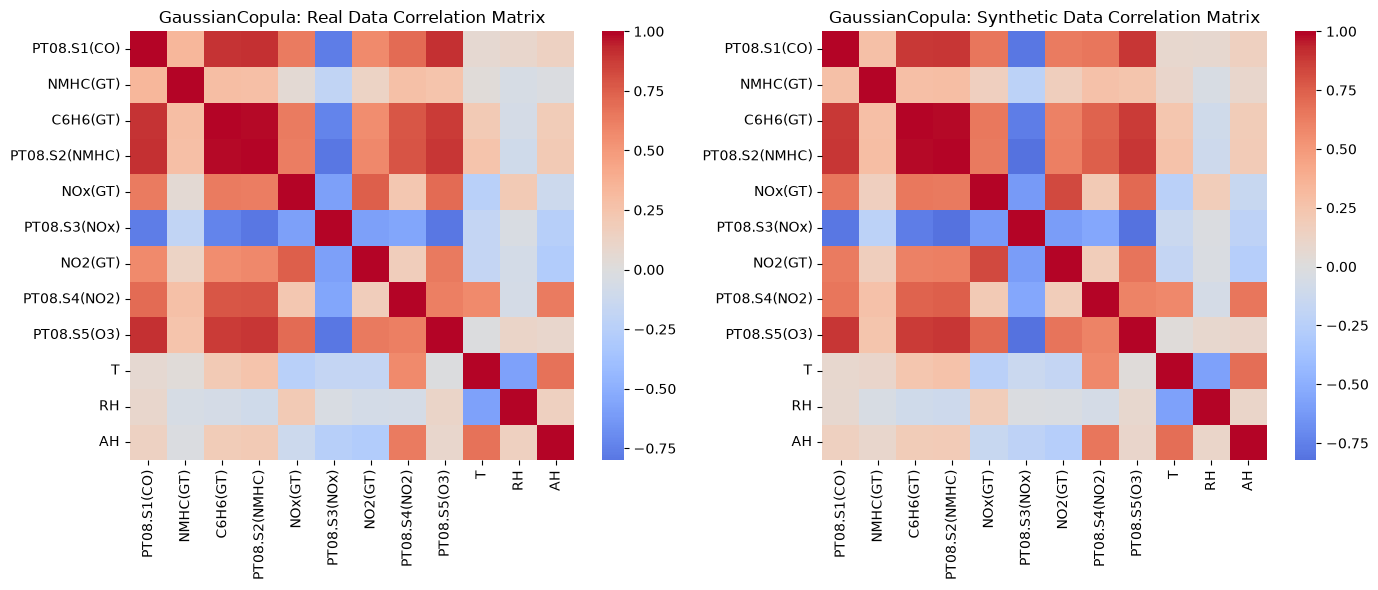

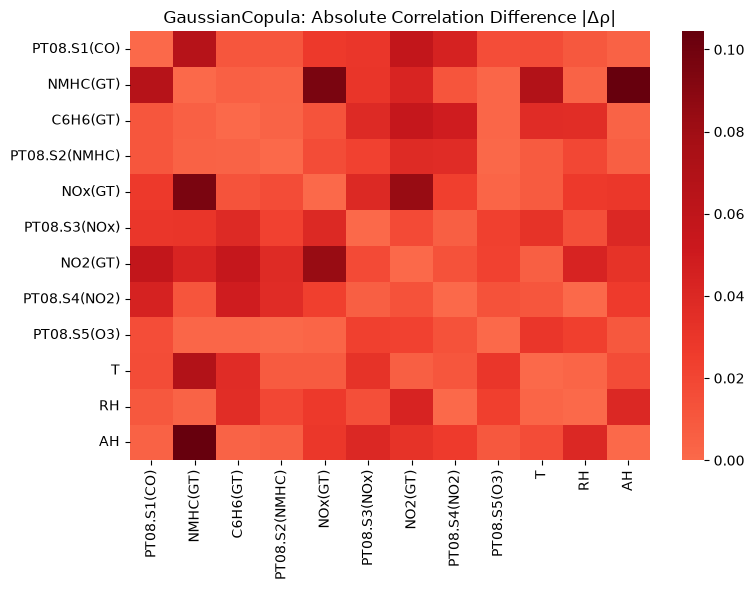

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
target_col = "CO(GT)"
id_col = None

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in [target_col, id_col] if c is not None]

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]
    synth_df = synth_df[_common]
    synth_corr = synth_df[num_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



CTGAN - Global MMD (RBF): 0.042712


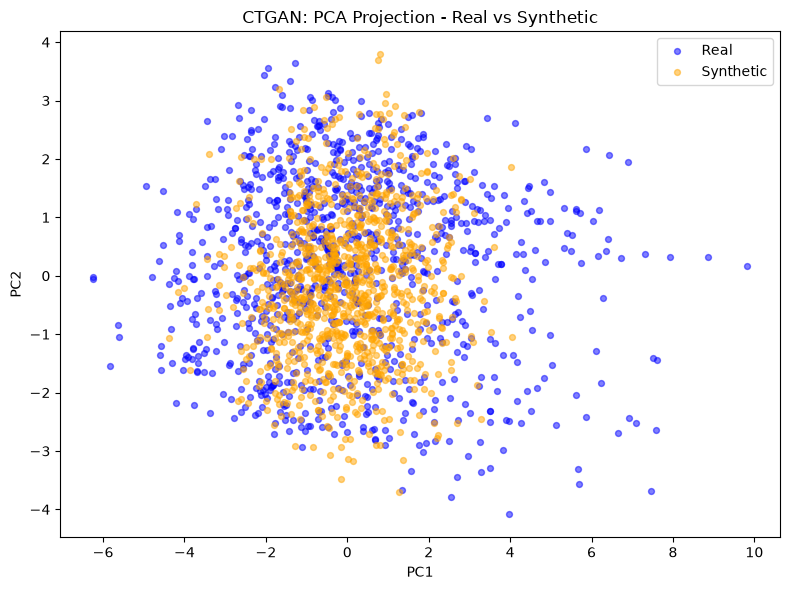

CTGAN - Two-Sample Classifier Accuracy: 0.9883

CopulaGAN - Global MMD (RBF): 0.144545


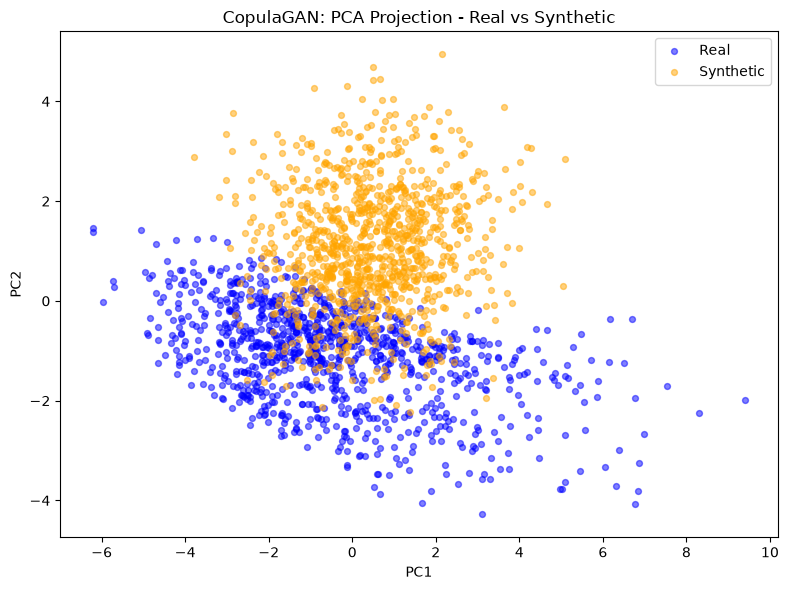

CopulaGAN - Two-Sample Classifier Accuracy: 0.9900

TVAE - Global MMD (RBF): 0.003989


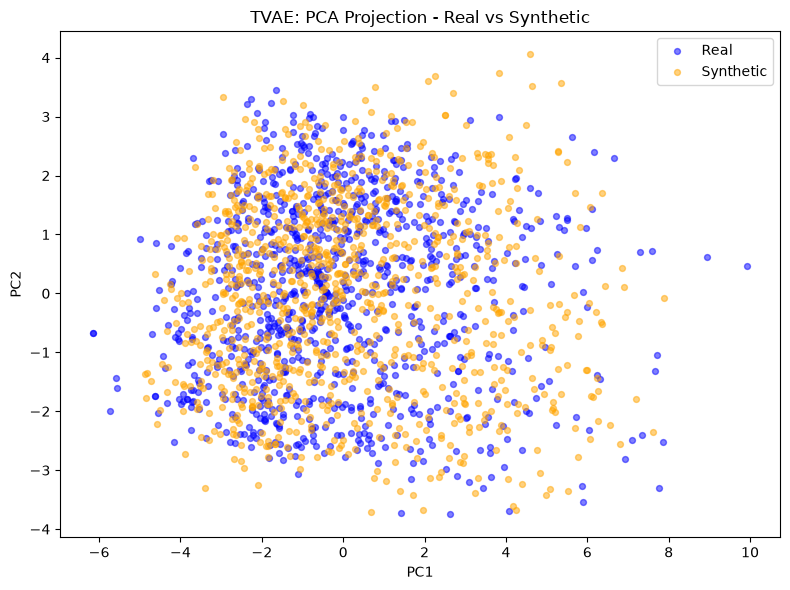

TVAE - Two-Sample Classifier Accuracy: 0.9367

GaussianCopula - Global MMD (RBF): 0.000198


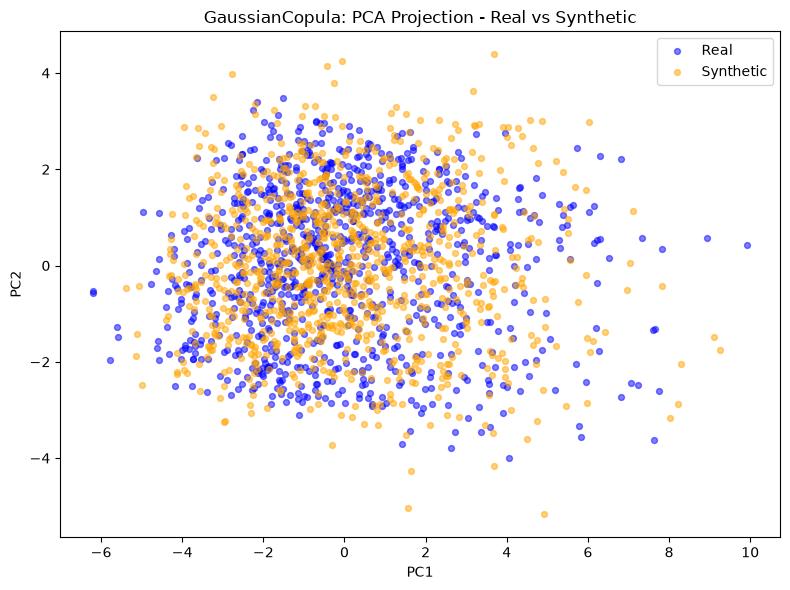

GaussianCopula - Two-Sample Classifier Accuracy: 0.9750

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,GaussianCopula,0.000198,0.975000
1,TVAE,0.003989,0.936667
2,CTGAN,0.042712,0.988333
3,CopulaGAN,0.144545,0.990000


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


def mmd_rbf(X, Y, gamma=None, gamma_sample_size=1500):
    if gamma is None:
        Z = np.vstack([X, Y])
        n = len(Z)
        k = min(gamma_sample_size, n)
        idx = np.random.default_rng(42).choice(n, size=k, replace=False)
        Zs = Z[idx]
        d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
        vals = d2[np.triu_indices_from(d2, k=1)]
        med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
        gamma = 1.0 / (2.0 * med)

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)

    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())


model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "CO(GT)"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

X_real_df = data.drop(columns=drop_cols, errors="ignore").copy()
results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real_df.columns.intersection(X_synth_df.columns)
    X_real = X_real_df[common_cols].to_numpy(dtype=np.float64)
    X_synth = X_synth_df[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestRegressor(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = r2_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": float(mmd_value),
        "C2ST_Accuracy": float(acc)
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)


# 4 Utility with 10 regressors 


In [29]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'SVR-RBF': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'ExtraTrees': ExtraTreesRegressor(random_state=42),
    'GradientBoost': GradientBoostingRegressor(random_state=42),
    'MLP': MLPRegressor(max_iter=2000, random_state=42)
}

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

def evaluate_models(train_df, test_df, label, models, test_size=0.2, seed=42):
    X_train = train_df.drop(columns=[label]).copy()
    y_train = train_df[label].copy()

    X_test = test_df.drop(columns=[label]).copy()
    y_test = test_df[label].copy()

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed
    )
    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed
    )

    num_cols = X_train.select_dtypes(include=[np.number]).columns

    X_train = X_train[num_cols].astype(np.float64)
    X_test = X_test[num_cols].astype(np.float64)

    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        results.append({
            "Model": name,
            "MAE": mean_absolute_error(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
            "R2": r2_score(y_test, preds)
        })

    return pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

In [31]:
import pandas as pd

label_col = "CO(GT)"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    _common = [c for c in data.columns if c in synthetic_datasets[synth_name].columns]
    synth_train = synthetic_datasets[synth_name][_common].copy()

    tstr_results = evaluate_models(
        train_df=synth_train,
        test_df=data,
        label=label_col,
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["MAE_Diff"] = comparison["MAE_TSTR"] - comparison["MAE_TRTR"]
    comparison["R2_Drop"] = comparison["R2_TRTR"] - comparison["R2_TSTR"]

    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("RMSE_Diff", ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

summary = (combined_comparison
          .groupby("Synthetic_Model", as_index=False)["RMSE_Diff"]
          .mean()
          .sort_values("RMSE_Diff"))

print("Average RMSE increase by synthetic generator (lower is better):")
display(summary)

TRTR (Train Real, Test Real)


,Model,MAE,RMSE,R2
0,ExtraTrees,0.340200,0.492043,0.873568
1,MLP,0.354799,0.497004,0.871005
2,GradientBoost,0.386423,0.532395,0.851980
3,SVR-RBF,0.364298,0.549154,0.842515
4,LinearRegression,0.396744,0.568646,0.831136
5,Ridge,0.396868,0.568851,0.831015
6,KNN,0.398500,0.583508,0.822194
7,RandomForest,0.378905,0.589886,0.818286
8,DecisionTree,0.480000,0.796178,0.668966
9,ElasticNet,0.616590,0.858210,0.615373


CTGAN - TSTR (Train Synthetic, Test Real)


,Model,MAE,RMSE,R2
0,LinearRegression,1.005040,1.343259,0.057738
1,Ridge,1.005016,1.343270,0.057722
2,ExtraTrees,1.000075,1.345213,0.054994
3,RandomForest,1.049580,1.367189,0.023867
4,Lasso,1.012337,1.385453,-0.002388
5,ElasticNet,1.012337,1.385453,-0.002388
6,SVR-RBF,1.003280,1.424540,-0.059744
7,GradientBoost,1.093718,1.459441,-0.112308
8,KNN,1.054800,1.480004,-0.143873
9,MLP,1.301035,1.700335,-0.509806


CTGAN - TRTR vs TSTR Comparison


...

,Model,MAE,RMSE,R2
0,LinearRegression,0.392943,0.581594,0.823359
1,Ridge,0.393123,0.581903,0.823171
2,GradientBoost,0.417435,0.633754,0.790254
3,ExtraTrees,0.453540,0.678169,0.759825
4,RandomForest,0.459990,0.707701,0.738452
5,MLP,0.505139,0.733334,0.719162
6,KNN,0.518500,0.753778,0.703285
7,SVR-RBF,0.485429,0.767672,0.692246
8,ElasticNet,0.649902,0.901530,0.575563
9,DecisionTree,0.792000,1.077590,0.393600


GaussianCopula - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,MAE_Diff,R2_Drop,Synthetic_Model
8,DecisionTree,0.480000,0.796178,0.668966,0.792000,1.077590,0.393600,0.281412,0.312000,0.275366,GaussianCopula
1,MLP,0.354799,0.497004,0.871005,0.505139,0.733334,0.719162,0.236330,0.150340,0.151843,GaussianCopula
3,SVR-RBF,0.364298,0.549154,0.842515,0.485429,0.767672,0.692246,0.218519,0.121131,0.150269,GaussianCopula
0,ExtraTrees,0.340200,0.492043,0.873568,0.453540,0.678169,0.759825,0.186126,0.113340,0.113742,GaussianCopula
6,KNN,0.398500,0.583508,0.822194,0.518500,0.753778,0.703285,0.170270,0.120000,0.118909,GaussianCopula
7,RandomForest,0.378905,0.589886,0.818286,0.459990,0.707701,0.738452,0.117815,0.081085,0.079834,GaussianCopula
2,GradientBoost,0.386423,0.532395,0.851980,0.417435,0.633754,0.790254,0.101359,0.031013,0.061726,GaussianCopula
10,Lasso,0.893524,1.259108,0.172100,0.947029,1.314424,0.097758,0.055316,0.053505,0.074341,GaussianCopula
9,ElasticNet,0.616590,0.858210,0.615373,0.649902,0.901530,0.575563,0.043320,0.033312,0.039810,GaussianCopula
5,Ridge,0.396868,0.568851,0.831015,0.393123,0.581903,0.823171,0.013052,-0.003745,0.007843,GaussianCopula


Average RMSE increase by synthetic generator (lower is better):


,Synthetic_Model,RMSE_Diff
2,GaussianCopula,0.130588
3,TVAE,0.678039
0,CTGAN,0.792570
1,CopulaGAN,1.035018


TRTR (Train Real, Test Real)


,Model,MAE,RMSE,R2
0,ExtraTrees,0.340200,0.492043,0.873568
1,MLP,0.354799,0.497004,0.871005
2,GradientBoost,0.386423,0.532395,0.851980
3,SVR-RBF,0.364298,0.549154,0.842515
4,LinearRegression,0.396744,0.568646,0.831136
5,Ridge,0.396868,0.568851,0.831015
6,KNN,0.398500,0.583508,0.822194
7,RandomForest,0.378905,0.589886,0.818286
8,DecisionTree,0.480000,0.796178,0.668966
9,ElasticNet,0.616590,0.858210,0.615373


CTGAN - TSTR (Train Synthetic, Test Real)


,Model,MAE,RMSE,R2
0,LinearRegression,1.005040,1.343259,0.057738
1,Ridge,1.005016,1.343270,0.057722
2,ExtraTrees,1.000075,1.345213,0.054994
3,RandomForest,1.049580,1.367189,0.023867
4,Lasso,1.012337,1.385453,-0.002388
5,ElasticNet,1.012337,1.385453,-0.002388
6,SVR-RBF,1.003280,1.424540,-0.059744
7,GradientBoost,1.093718,1.459441,-0.112308
8,KNN,1.054800,1.480004,-0.143873
9,MLP,1.301035,1.700335,-0.509806


CTGAN - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,MAE_Diff,R2_Drop,Synthetic_Model
1,MLP,0.354799,0.497004,0.871005,1.301035,1.700335,-0.509806,1.203331,0.946236,1.380811,CTGAN
8,DecisionTree,0.480000,0.796178,0.668966,1.289000,1.779101,-0.652926,0.982923,0.809000,1.321891,CTGAN
2,GradientBoost,0.386423,0.532395,0.851980,1.093718,1.459441,-0.112308,0.927046,0.707295,0.964288,CTGAN
6,KNN,0.398500,0.583508,0.822194,1.054800,1.480004,-0.143873,0.896496,0.656300,0.966067,CTGAN
3,SVR-RBF,0.364298,0.549154,0.842515,1.003280,1.424540,-0.059744,0.875386,0.638982,0.902259,CTGAN
0,ExtraTrees,0.340200,0.492043,0.873568,1.000075,1.345213,0.054994,0.853171,0.659875,0.818574,CTGAN
7,RandomForest,0.378905,0.589886,0.818286,1.049580,1.367189,0.023867,0.777303,0.670675,0.794419,CTGAN
4,LinearRegression,0.396744,0.568646,0.831136,1.005040,1.343259,0.057738,0.774613,0.608295,0.773398,CTGAN
5,Ridge,0.396868,0.568851,0.831015,1.005016,1.343270,0.057722,0.774419,0.608147,0.773292,CTGAN
9,ElasticNet,0.616590,0.858210,0.615373,1.012337,1.385453,-0.002388,0.527243,0.395747,0.617761,CTGAN


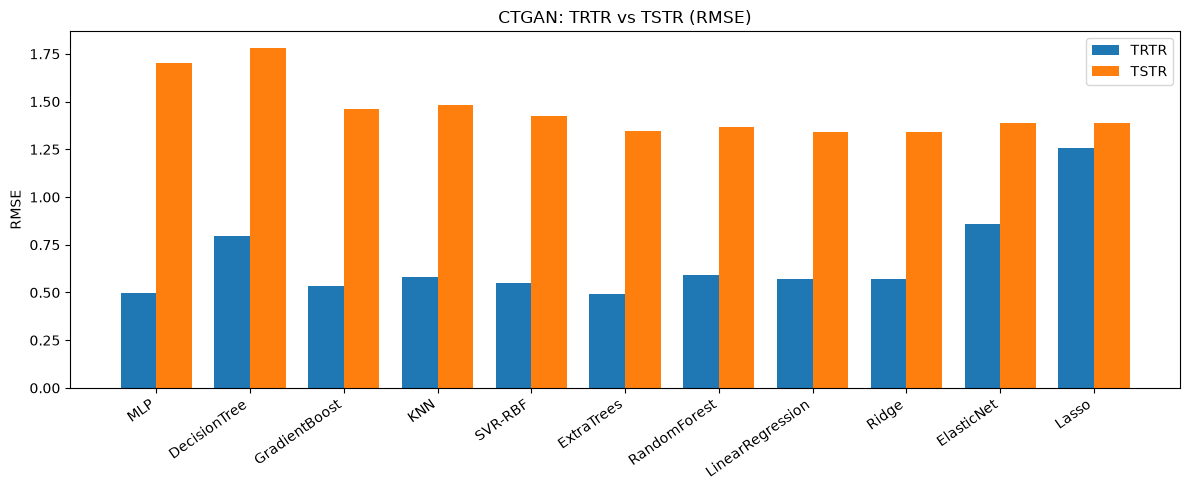

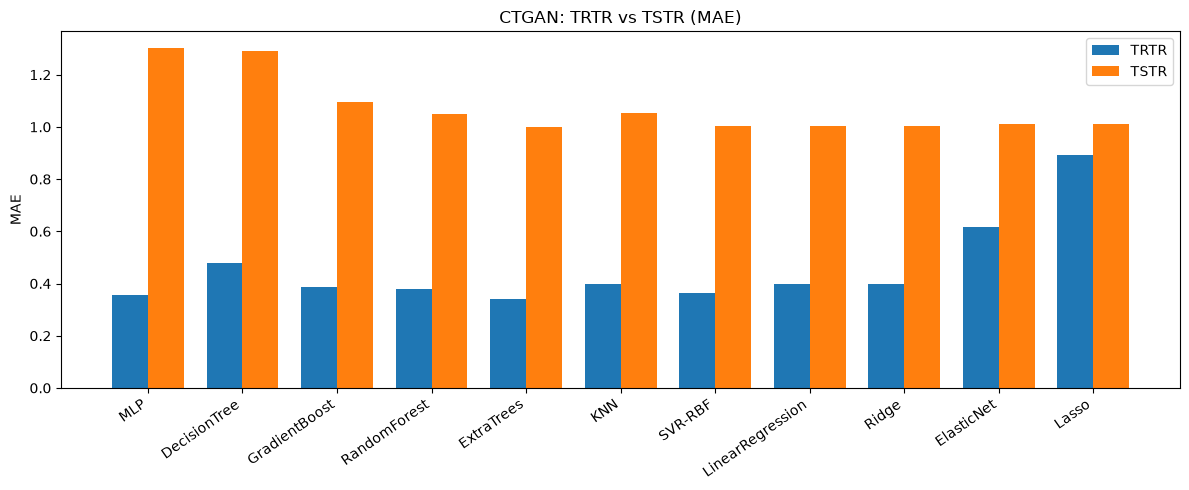

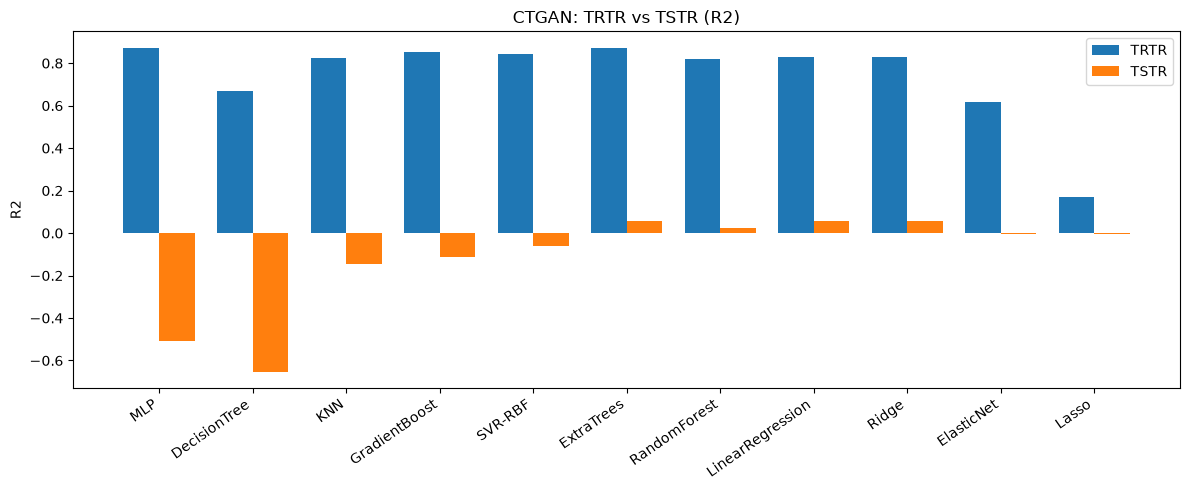

CopulaGAN - TSTR (Train Synthetic, Test Real)


,Model,MAE,RMSE,R2
0,Ridge,0.915662,1.235842,0.202413
1,LinearRegression,0.915849,1.235852,0.202400
2,ExtraTrees,1.083770,1.358705,0.035943
3,Lasso,0.931787,1.401536,-0.025795
4,ElasticNet,0.931787,1.401536,-0.025795
5,SVR-RBF,0.942433,1.426588,-0.062794
6,KNN,1.050000,1.454125,-0.104220
7,RandomForest,1.157195,1.495031,-0.167219
8,GradientBoost,1.210789,1.592657,-0.324637
9,MLP,1.768496,2.338047,-1.854687


CopulaGAN - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,MAE_Diff,R2_Drop,Synthetic_Model
8,DecisionTree,0.480000,0.796178,0.668966,2.518500,3.740261,-6.305600,2.944082,2.038500,6.974566,CopulaGAN
1,MLP,0.354799,0.497004,0.871005,1.768496,2.338047,-1.854687,1.841042,1.413697,2.725692,CopulaGAN
2,GradientBoost,0.386423,0.532395,0.851980,1.210789,1.592657,-0.324637,1.060262,0.824366,1.176617,CopulaGAN
7,RandomForest,0.378905,0.589886,0.818286,1.157195,1.495031,-0.167219,0.905145,0.778290,0.985505,CopulaGAN
3,SVR-RBF,0.364298,0.549154,0.842515,0.942433,1.426588,-0.062794,0.877434,0.578135,0.905309,CopulaGAN
6,KNN,0.398500,0.583508,0.822194,1.050000,1.454125,-0.104220,0.870617,0.651500,0.926414,CopulaGAN
0,ExtraTrees,0.340200,0.492043,0.873568,1.083770,1.358705,0.035943,0.866662,0.743570,0.837625,CopulaGAN
4,LinearRegression,0.396744,0.568646,0.831136,0.915849,1.235852,0.202400,0.667207,0.519104,0.628737,CopulaGAN
5,Ridge,0.396868,0.568851,0.831015,0.915662,1.235842,0.202413,0.666991,0.518794,0.628602,CopulaGAN
9,ElasticNet,0.616590,0.858210,0.615373,0.931787,1.401536,-0.025795,0.543326,0.315197,0.641168,CopulaGAN


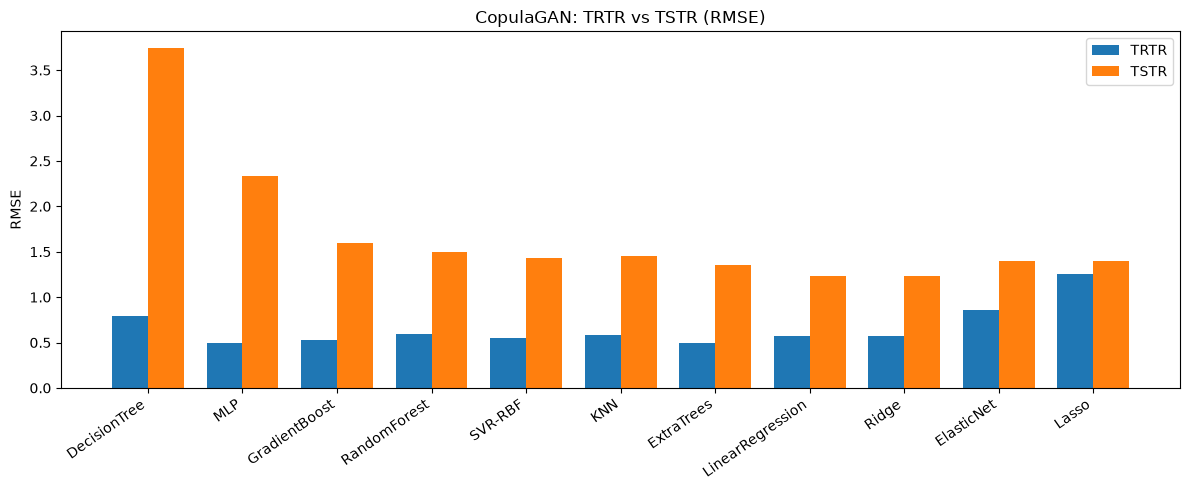

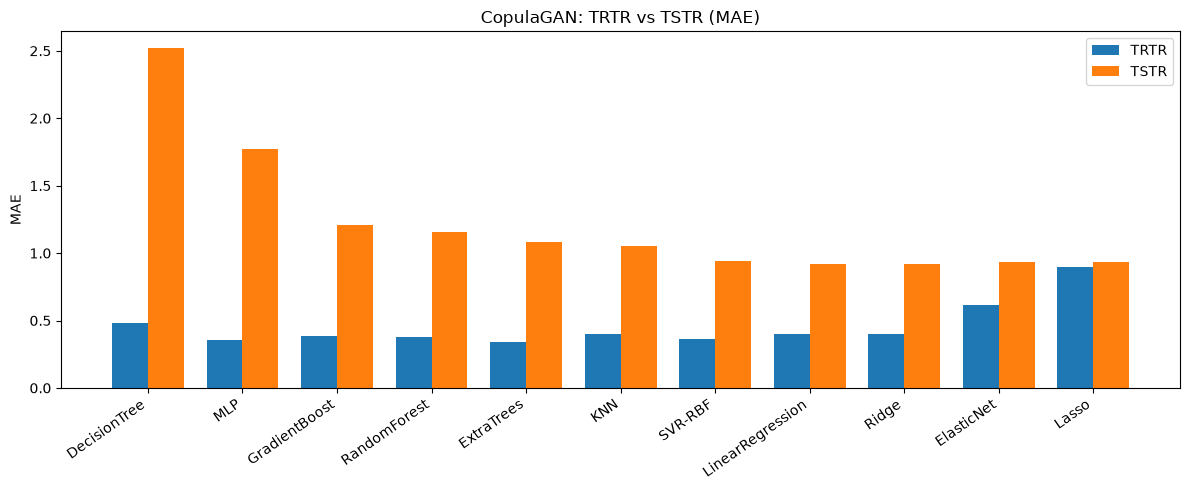

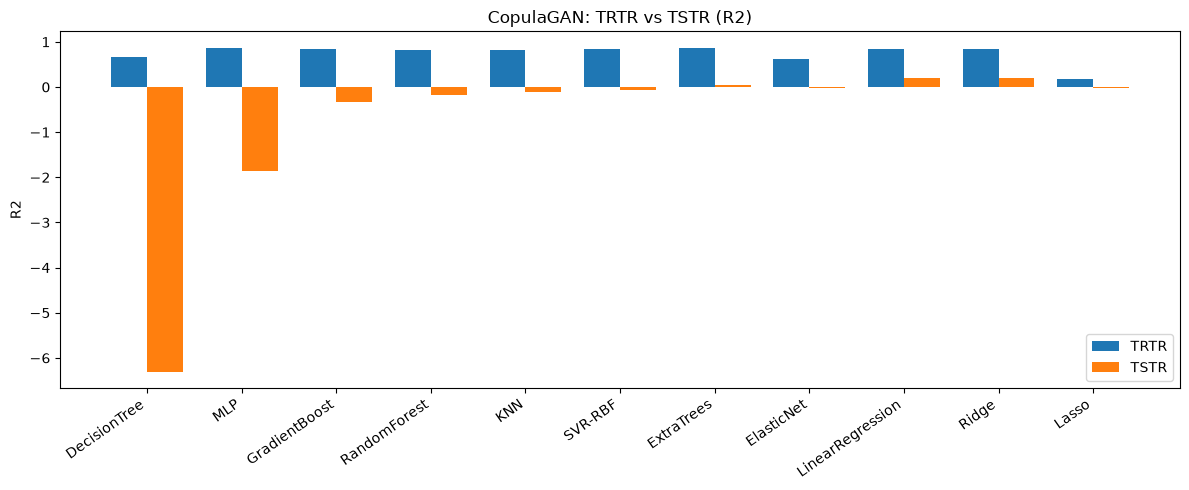

TVAE - TSTR (Train Synthetic, Test Real)


,Model,MAE,RMSE,R2
0,RandomForest,0.494825,0.726316,0.724511
1,ExtraTrees,0.489980,0.730051,0.721671
2,GradientBoost,0.490477,0.733155,0.719299
3,KNN,0.553600,0.810269,0.657145
4,SVR-RBF,0.540721,0.821006,0.647998
5,ElasticNet,0.701477,0.979116,0.499366
6,DecisionTree,0.865500,1.233552,0.205366
7,LinearRegression,0.681306,1.299384,0.118287
8,Ridge,0.681516,1.299963,0.117501
9,Lasso,0.993901,1.368717,0.021684


TVAE - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,MAE_Diff,R2_Drop,Synthetic_Model
1,MLP,0.354799,0.497004,0.871005,1.336555,4.751878,-10.791870,4.254874,0.981756,11.662875,TVAE
5,Ridge,0.396868,0.568851,0.831015,0.681516,1.299963,0.117501,0.731113,0.284647,0.713514,TVAE
4,LinearRegression,0.396744,0.568646,0.831136,0.681306,1.299384,0.118287,0.730738,0.284561,0.712849,TVAE
8,DecisionTree,0.480000,0.796178,0.668966,0.865500,1.233552,0.205366,0.437373,0.385500,0.463599,TVAE
3,SVR-RBF,0.364298,0.549154,0.842515,0.540721,0.821006,0.647998,0.271852,0.176423,0.194516,TVAE
0,ExtraTrees,0.340200,0.492043,0.873568,0.489980,0.730051,0.721671,0.238008,0.149780,0.151897,TVAE
6,KNN,0.398500,0.583508,0.822194,0.553600,0.810269,0.657145,0.226761,0.155100,0.165049,TVAE
2,GradientBoost,0.386423,0.532395,0.851980,0.490477,0.733155,0.719299,0.200760,0.104055,0.132681,TVAE
7,RandomForest,0.378905,0.589886,0.818286,0.494825,0.726316,0.724511,0.136431,0.115920,0.093775,TVAE
9,ElasticNet,0.616590,0.858210,0.615373,0.701477,0.979116,0.499366,0.120906,0.084887,0.116007,TVAE


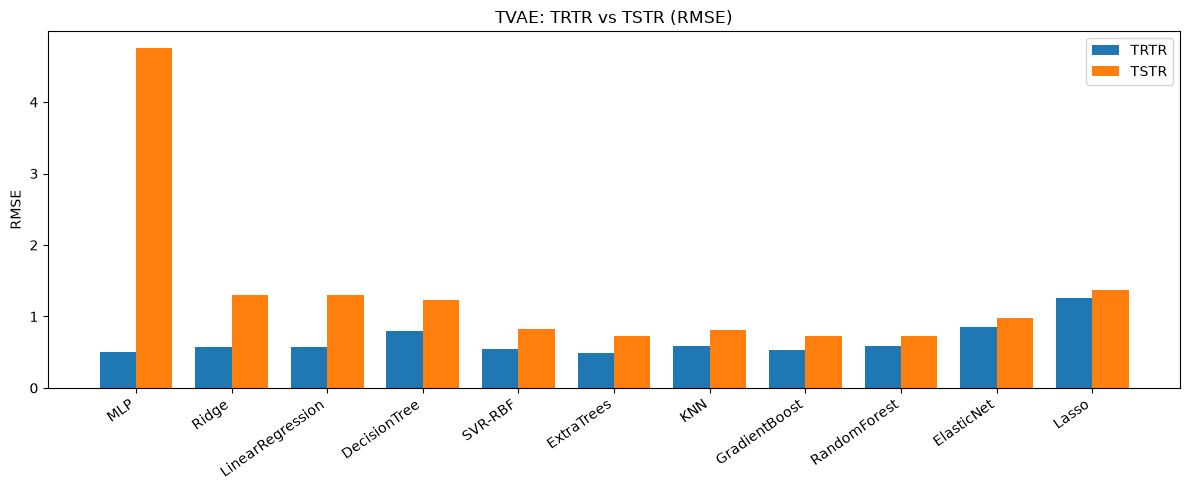

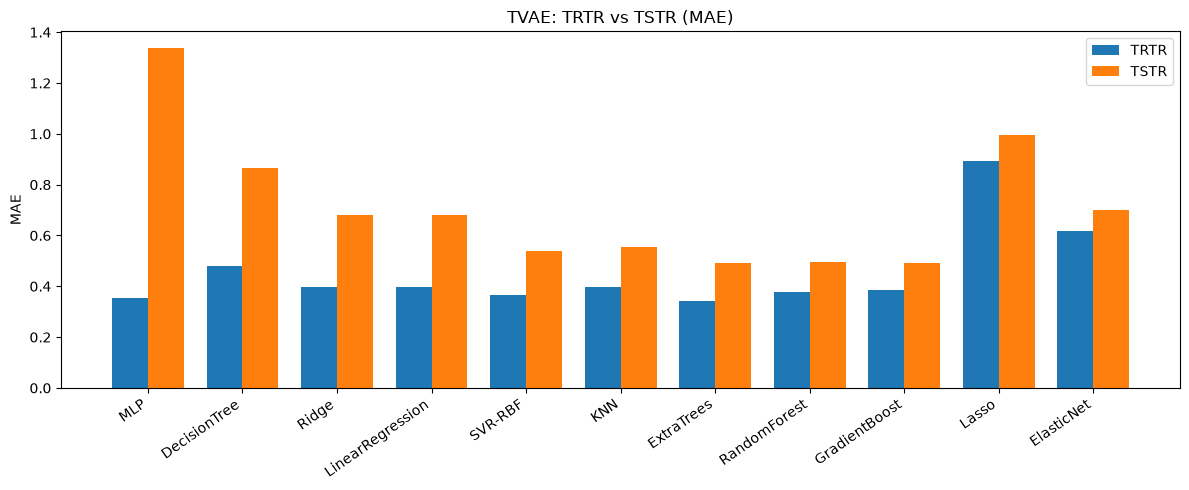

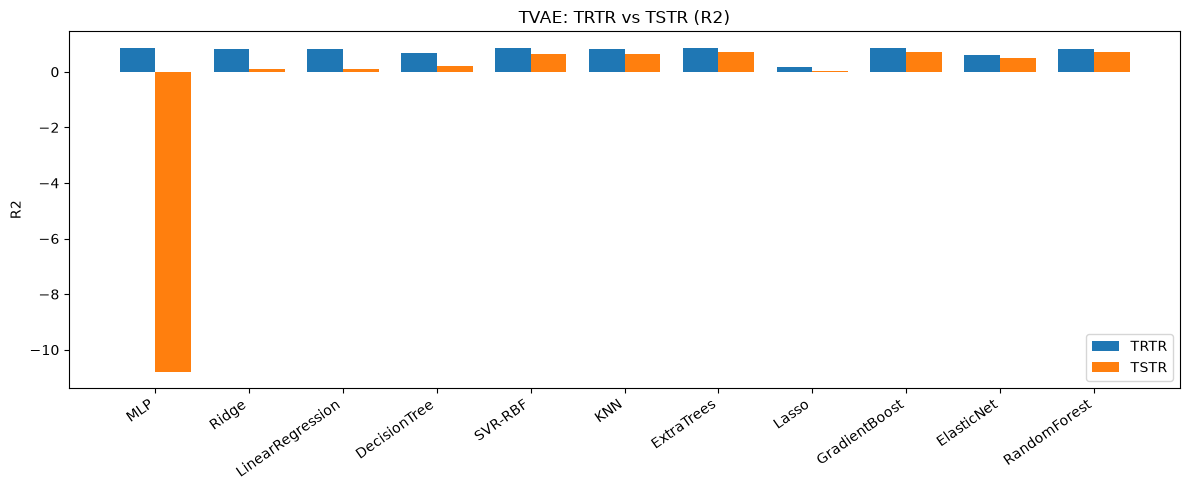

GaussianCopula - TSTR (Train Synthetic, Test Real)


,Model,MAE,RMSE,R2
0,LinearRegression,0.392943,0.581594,0.823359
1,Ridge,0.393123,0.581903,0.823171
2,GradientBoost,0.417435,0.633754,0.790254
3,ExtraTrees,0.453540,0.678169,0.759825
4,RandomForest,0.459990,0.707701,0.738452
5,MLP,0.505139,0.733334,0.719162
6,KNN,0.518500,0.753778,0.703285
7,SVR-RBF,0.485429,0.767672,0.692246
8,ElasticNet,0.649902,0.901530,0.575563
9,DecisionTree,0.792000,1.077590,0.393600


GaussianCopula - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,MAE_Diff,R2_Drop,Synthetic_Model
8,DecisionTree,0.480000,0.796178,0.668966,0.792000,1.077590,0.393600,0.281412,0.312000,0.275366,GaussianCopula
1,MLP,0.354799,0.497004,0.871005,0.505139,0.733334,0.719162,0.236330,0.150340,0.151843,GaussianCopula
3,SVR-RBF,0.364298,0.549154,0.842515,0.485429,0.767672,0.692246,0.218519,0.121131,0.150269,GaussianCopula
0,ExtraTrees,0.340200,0.492043,0.873568,0.453540,0.678169,0.759825,0.186126,0.113340,0.113742,GaussianCopula
6,KNN,0.398500,0.583508,0.822194,0.518500,0.753778,0.703285,0.170270,0.120000,0.118909,GaussianCopula
7,RandomForest,0.378905,0.589886,0.818286,0.459990,0.707701,0.738452,0.117815,0.081085,0.079834,GaussianCopula
2,GradientBoost,0.386423,0.532395,0.851980,0.417435,0.633754,0.790254,0.101359,0.031013,0.061726,GaussianCopula
10,Lasso,0.893524,1.259108,0.172100,0.947029,1.314424,0.097758,0.055316,0.053505,0.074341,GaussianCopula
9,ElasticNet,0.616590,0.858210,0.615373,0.649902,0.901530,0.575563,0.043320,0.033312,0.039810,GaussianCopula
5,Ridge,0.396868,0.568851,0.831015,0.393123,0.581903,0.823171,0.013052,-0.003745,0.007843,GaussianCopula


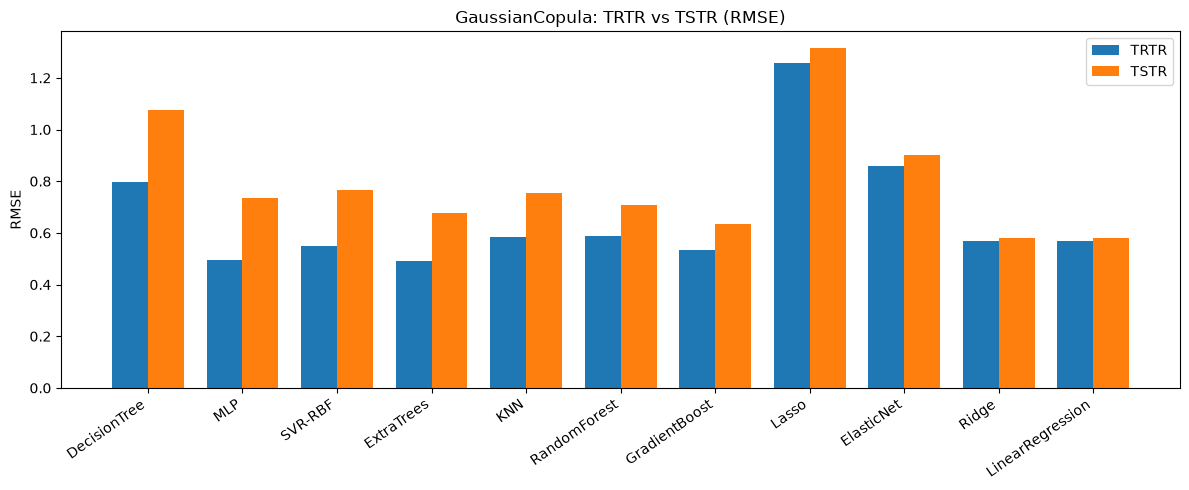

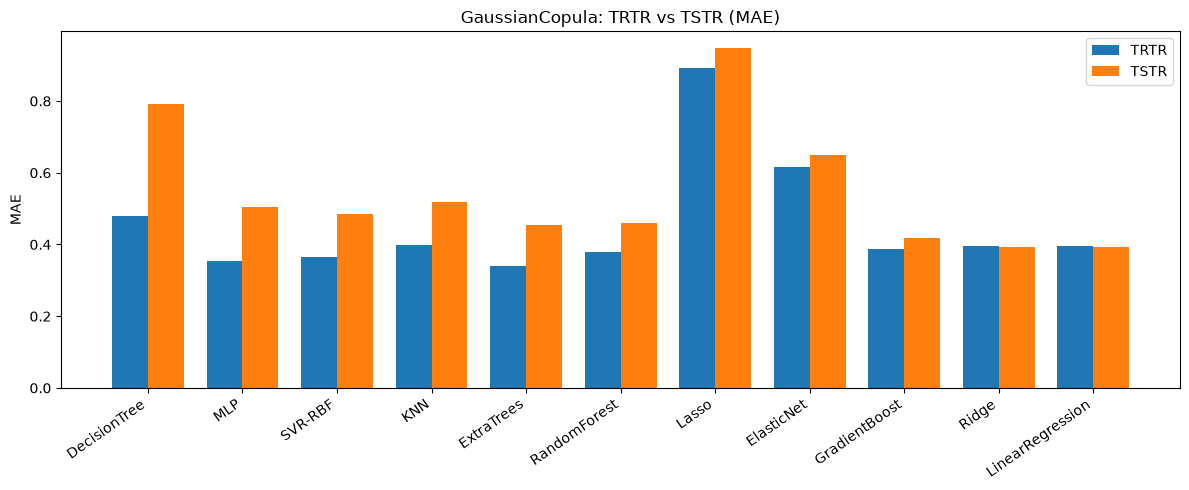

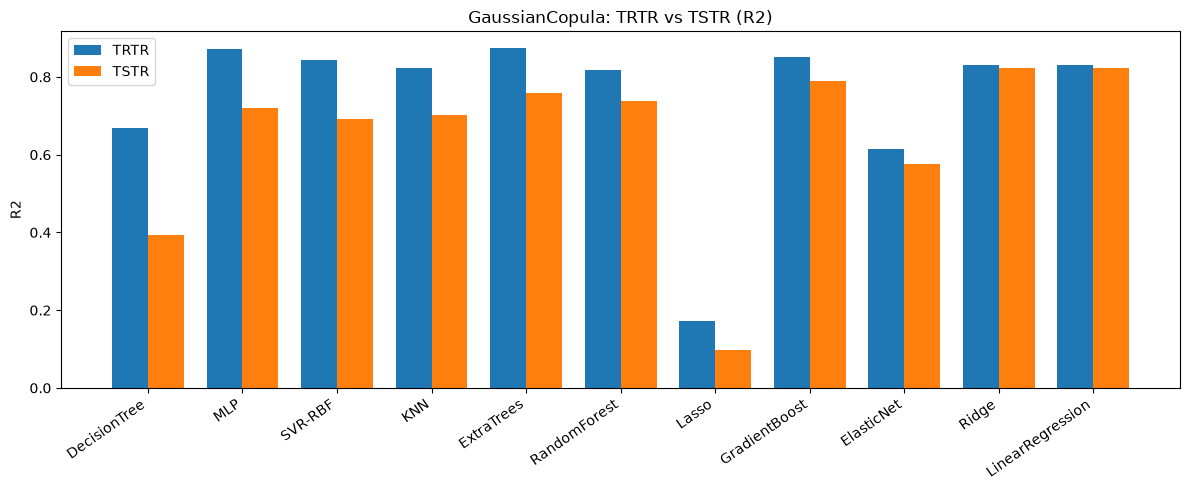

Average RMSE increase by synthetic generator (lower is better):


,Synthetic_Model,RMSE_Diff
2,GaussianCopula,0.130588
3,TVAE,0.678039
0,CTGAN,0.792570
1,CopulaGAN,1.035018


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="RMSE"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    if metric in ["MAE", "RMSE"]:
        df["Diff"] = df[f"{metric}_TSTR"] - df[f"{metric}_TRTR"]
    else:
        df["Diff"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]

    df = df.sort_values("Diff", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label="TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label="TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_metric_diff(comparison_df, synth_name, metric):
    if metric not in comparison_df.columns:
        return

    df = comparison_df.sort_values(metric, ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df[metric])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: {metric}")
    plt.tight_layout()
    plt.show()

label_col = "CO(GT)"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label=label_col,
    models=models
)

all_comp = []

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

for synth_name in model_order:
    _common = [c for c in data.columns if c in synthetic_datasets[synth_name].columns]
    synth_train = synthetic_datasets[synth_name][_common].copy()

    tstr_results = evaluate_models(
        train_df=synth_train,
        test_df=data,
        label=label_col,
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["MAE_Diff"] = comparison["MAE_TSTR"] - comparison["MAE_TRTR"]
    comparison["R2_Drop"] = comparison["R2_TRTR"] - comparison["R2_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("RMSE_Diff", ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comp.append(comparison)

    for metric in ["RMSE", "MAE", "R2"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_rmse = (
    combined_comparison.dropna(subset=["RMSE_Diff"])
    .groupby("Synthetic_Model", as_index=False)["RMSE_Diff"]
    .mean()
    .sort_values("RMSE_Diff")
)

print("Average RMSE increase by synthetic generator (lower is better):")
display(summary_rmse)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def _metric_delta(metric, trtr_val, tstr_val):
    if metric in ("RMSE", "MAE"):
        return tstr_val - trtr_val
    if metric == "R2":
        return trtr_val - tstr_val
    return trtr_val - tstr_val

def plot_grid_line_metrics_with_gap(trtr_results, tstr_results, generator_name, ncols=5):
    metrics = [m for m in ["RMSE", "MAE", "R2"] if m in trtr_results.columns and m in tstr_results.columns]
    if not metrics:
        metrics = [m for m in ["Accuracy", "F1", "AUC"] if m in trtr_results.columns and m in tstr_results.columns]
    if not metrics:
        print(f"No common metrics found for {generator_name}.")
        return

    x = np.arange(len(metrics))
    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(22, max(9, 3 * nrows)), dpi=150, constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for i, model_name in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[model_name].values.astype(float)
        b = tstr.loc[model_name].values.astype(float)
        deltas = [_metric_delta(m, ai, bi) for m, ai, bi in zip(metrics, a, b)]

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="s", label="TSTR")
        ax.fill_between(x, np.minimum(a, b), np.maximum(a, b), alpha=0.2)

        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        for xi, ai, bi, di in zip(x, a, b, deltas):
            ax.text(xi, (ai + bi) / 2, f"{di:+.3f}", ha="center", va="center", fontsize=8)

        ax.set_title(model_name, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="best")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"{generator_name} - TRTR vs TSTR per regressor", fontsize=14)
    plt.show()

label_col = "CO(GT)"
generators = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
trtr_results = evaluate_models(train_df=data, test_df=data, label=label_col, models=models)
for gen in generators:
    _common = [c for c in data.columns if c in synthetic_datasets[gen].columns]
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[gen][_common],
        test_df=data,
        label=label_col,
        models=models,
    )
    plot_grid_line_metrics_with_gap(trtr_results, tstr_results, generator_name=gen, ncols=5)


# 5 Statistical similarity tests 

Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,9.909676,10.561894,20.589940
1,CopulaGAN,24.239754,16.724502,22.040592
2,TVAE,2.709966,1.993973,18.624893
3,GaussianCopula,0.869365,0.761840,4.148811


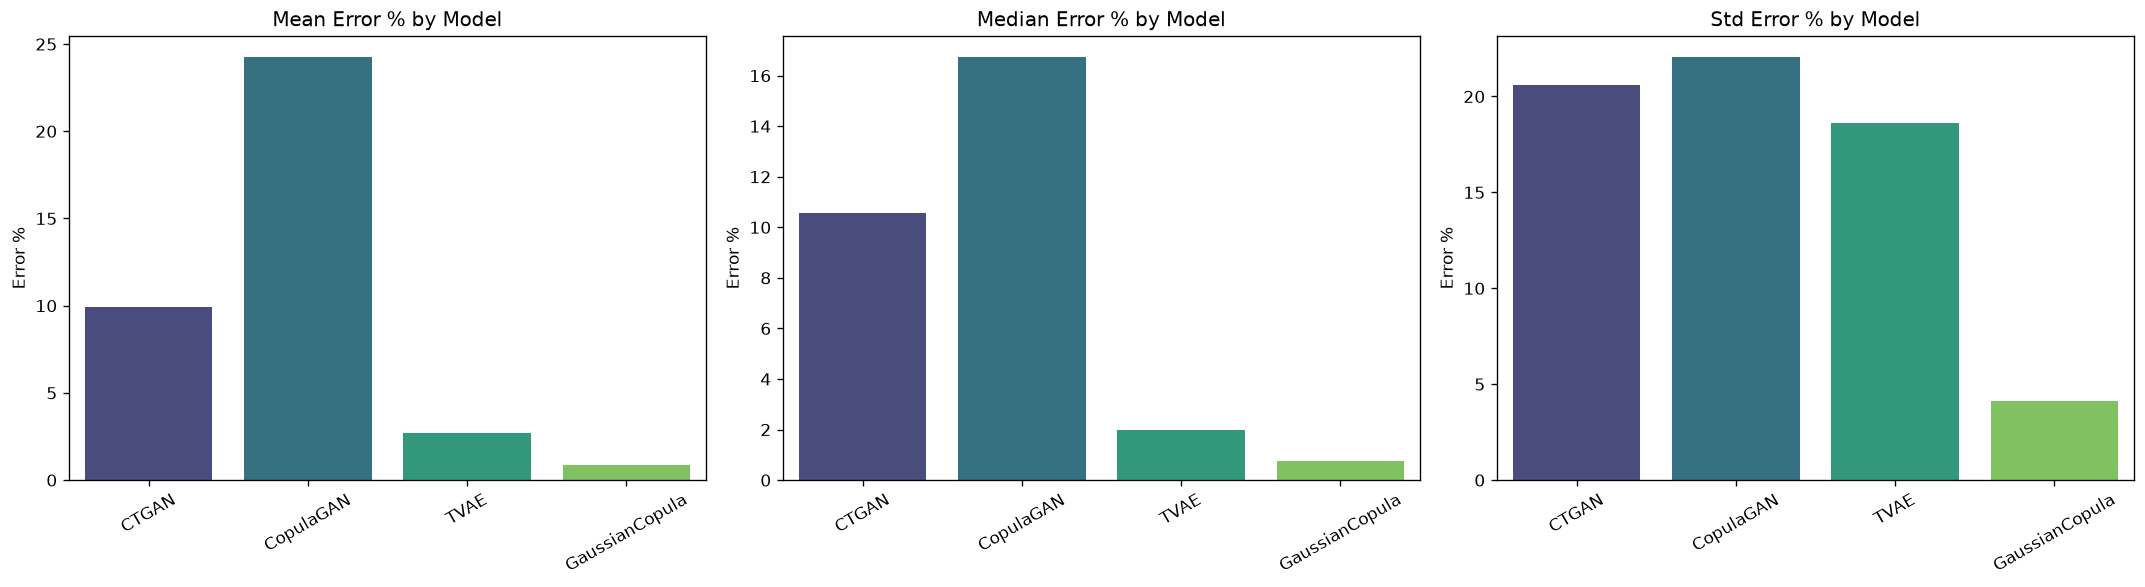

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "CO(GT)"]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]
    synth_df = synth_df[_common]

    real_means = real_df[num_cols].astype(np.float64).mean()
    synth_means = synth_df[num_cols].astype(np.float64).mean()

    real_stds = real_df[num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()

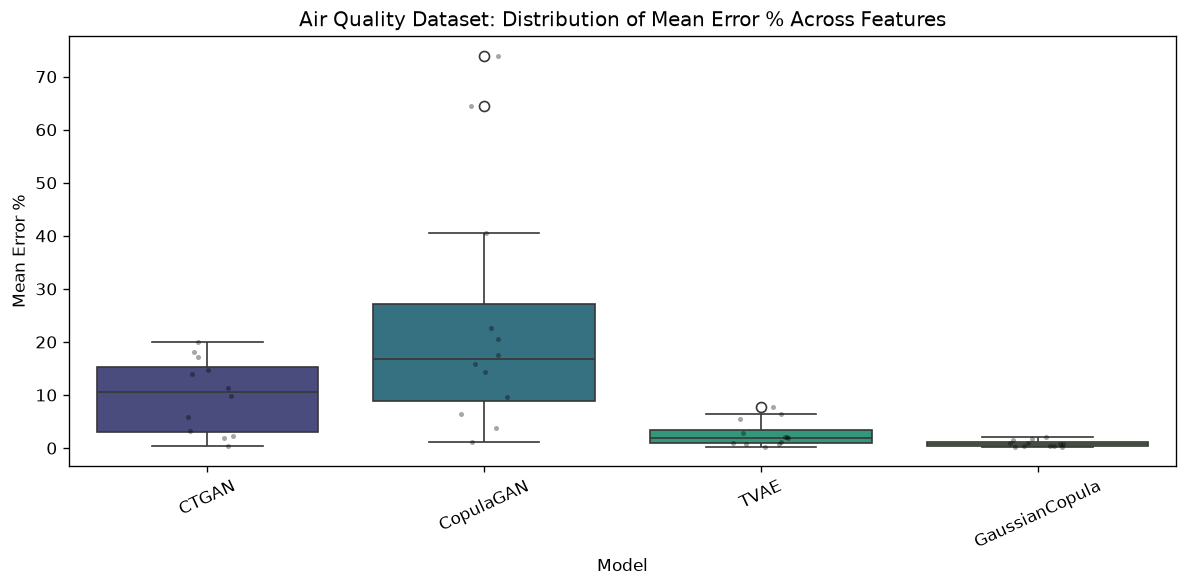

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Air Quality Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

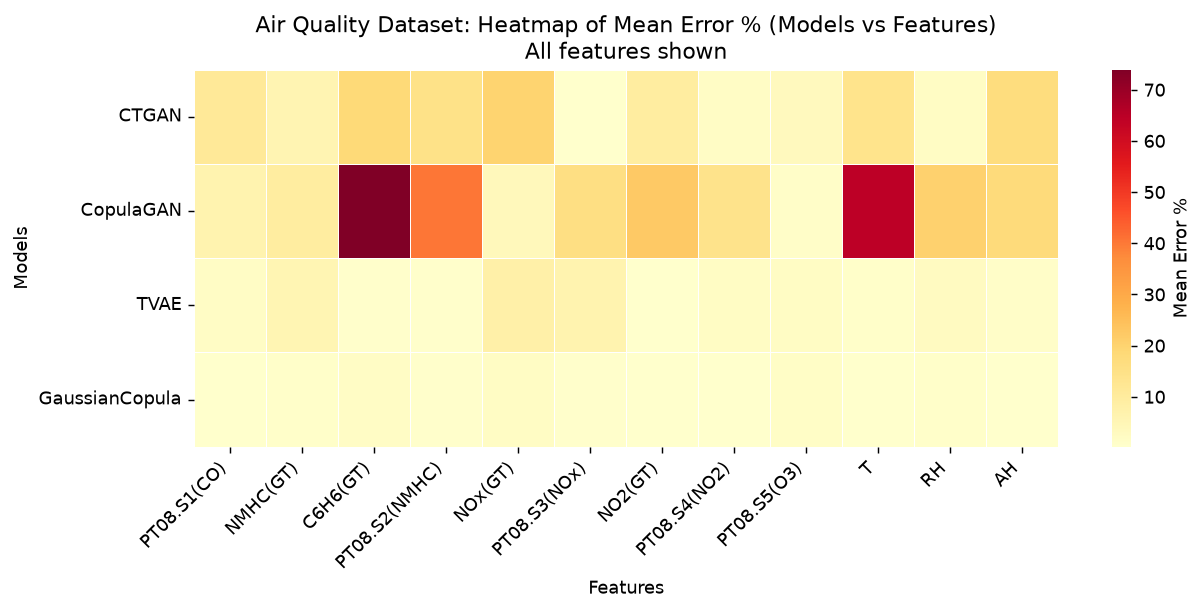

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Air Quality Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

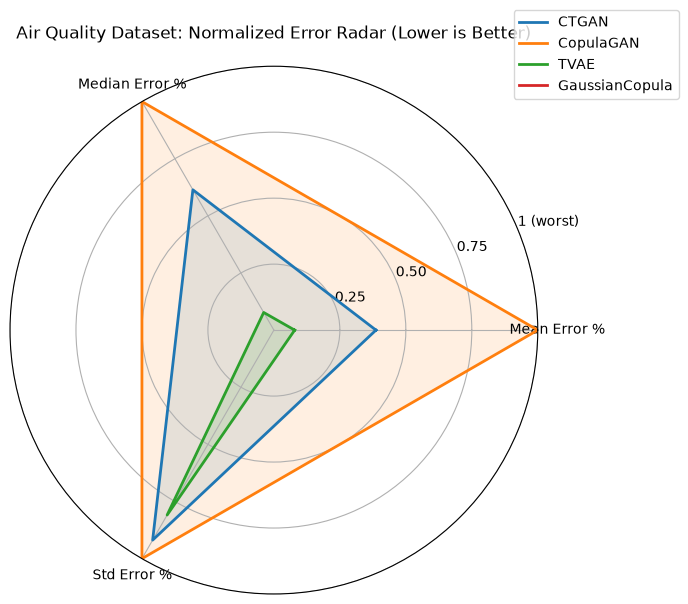

,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,0.386828,0.613936,0.918921
1,CopulaGAN,1.000000,1.000000,1.000000
2,TVAE,0.078758,0.077188,0.809091
3,GaussianCopula,0.000000,0.000000,0.000000


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
radar_df = summary_df[["Model"] + metrics].copy()

norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Air Quality Dataset: Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))

plt.tight_layout()
plt.show()

display(norm_df)

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,CTGAN,15.416667,9.0,40.0
1,GaussianCopula,16.333333,10.0,84.0
2,CopulaGAN,23.333333,14.0,103.0
3,TVAE,24.916667,7.0,107.0


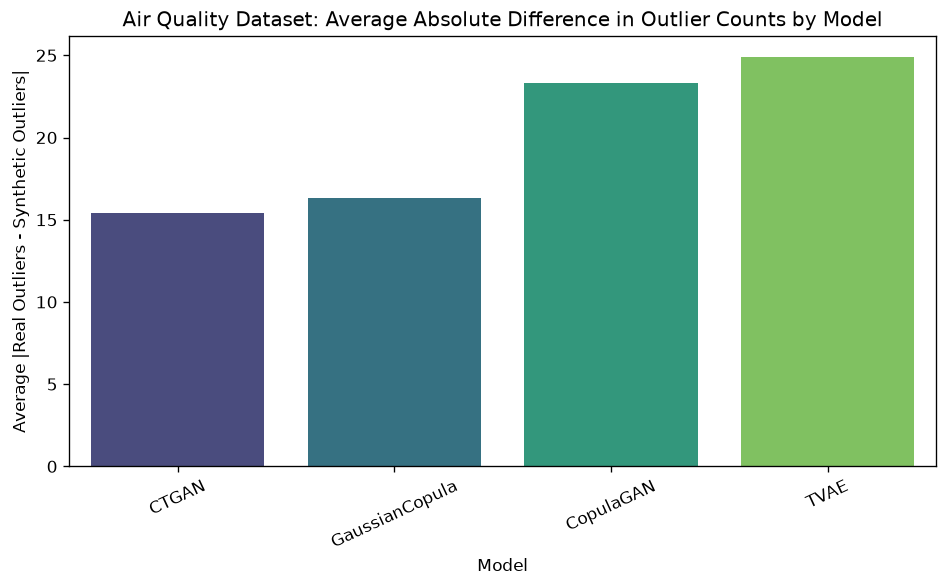

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "CO(GT)"]

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_datasets[model][real_df.columns].copy()
    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in num_cols}

    feat_df = pd.DataFrame({
        "Feature": num_cols,
        "Real_Outliers": [real_outliers[c] for c in num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].mean()),
        "Median_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].median()),
        "Max_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].max())
    })

outlier_summary_df = pd.DataFrame(rows).sort_values("Avg_Abs_Diff_Outlier_Count").reset_index(drop=True)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")
plt.title("Air Quality Dataset: Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# 6. Cosine Similarity with Hungraian Mapping

In [39]:
from numpy.linalg import norm
import numpy as np
import pandas as pd
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer

if "ctgan" not in globals():
    ctgan = CTGANSynthesizer(metadata=metadata)
    ctgan.fit(data)

if "copulagan" not in globals():
    copulagan = CopulaGANSynthesizer(metadata=metadata)
    copulagan.fit(data)

if "tvae" not in globals():
    tvae = TVAESynthesizer(metadata=metadata)
    tvae.fit(data)

if "gaussiancopula" not in globals():
    gaussiancopula = GaussianCopulaSynthesizer(metadata=metadata)
    gaussiancopula.fit(data)

synth_models = {
    "CTGAN": ctgan,
    "CopulaGAN": copulagan,
    "TVAE": tvae,
    "GaussianCopula": gaussiancopula
}

n_rows = len(data)
synthetic_data = {}
for name, synth in synth_models.items():
    synthetic_data[name] = synth.sample(num_rows=n_rows)[data.columns]

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

cosine_results = {}
cosine_dfs = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "CO(GT)"]

real_matrix = normalize_rows(data[num_cols].to_numpy(dtype=np.float64))

for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy(dtype=np.float64))
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)

Building cosine similarity DataFrame for CTGAN...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.929878  0.991404  0.970276  0.983818  0.971711  0.963755  0.925732   
R2   0.918122  0.986319  0.973713  0.979568  0.972714  0.962087  0.921716   
R3   0.912161  0.962434  0.958995  0.954915  0.932499  0.986663  0.959561   
R4   0.909273  0.951589  0.950071  0.949234  0.911163  0.980206  0.951970   
R5   0.920966  0.960551  0.907980  0.926565  0.925999  0.980575  0.987154   
R6   0.932776  0.993522  0.961177  0.978457  0.971314  0.975544  0.952010   
R7   0.928460  0.979094  0.928285  0.952037  0.960303  0.981910  0.983068   
R8   0.924977  0.984496  0.981338  0.988560  0.972368  0.976388  0.935765   
R9   0.919134  0.987178  0.980461  0.986604  0.969951  0.975195  0.938455   
R10  0.929883  0.980337  0.923469  0.949279  0.953135  0.939495  0.917635   

           S8        S9       S10  
R1   0.932260  0.949028  0.994843  
R2   0.940051  0.951657  0.993

,avg_cosine,max_cosine
CTGAN,0.929650,0.999706
CopulaGAN,0.926552,0.999562
TVAE,0.954445,0.999895
GaussianCopula,0.954558,0.999879


In [40]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c != "CO(GT)"]

    R = real_data[num_cols].to_numpy(dtype=np.float64)
    S = synthetic_data[num_cols].to_numpy(dtype=np.float64)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns].copy()
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")



CTGAN - Top 10 Real -> Synthetic Matchings
01. R254 -> S206   cosine similarity = 0.9997
02. R901 -> S206   cosine similarity = 0.9996
03. R210 -> S206   cosine similarity = 0.9996
04. R519 -> S206   cosine similarity = 0.9996
05. R588 -> S206   cosine similarity = 0.9996
06. R392 -> S206   cosine similarity = 0.9996
07. R974 -> S576   cosine similarity = 0.9995
08. R40 -> S576   cosine similarity = 0.9995
09. R625 -> S206   cosine similarity = 0.9995
10. R853 -> S488   cosine similarity = 0.9994

CopulaGAN - Top 10 Real -> Synthetic Matchings
01. R811 -> S232   cosine similarity = 0.9996
02. R819 -> S330   cosine similarity = 0.9996
03. R255 -> S330   cosine similarity = 0.9995
04. R502 -> S232   cosine similarity = 0.9995
05. R836 -> S562   cosine similarity = 0.9995
06. R547 -> S330   cosine similarity = 0.9995
07. R379 -> S86   cosine similarity = 0.9995
08. R982 -> S440   cosine similarity = 0.9994
09. R590 -> S766   cosine similarity = 0.9994
10. R813 -> S785   cosine similarity

In [41]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

def normalize_rows(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != "CO(GT)"]

    R = real_df[num_cols].to_numpy(dtype=np.float64)
    S = synth_df[num_cols].to_numpy(dtype=np.float64)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = data.copy()
results = {}

for name in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features excluding CO(GT))")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")



CTGAN: Hungarian matching (cosine, numeric features excluding CO(GT))
Average cosine similarity (Hungarian match): 0.9741

R453 <-> S206   cosine similarity = 0.9993
R446 <-> S109   cosine similarity = 0.9992
R495 <-> S888   cosine similarity = 0.9986
R215 <-> S513   cosine similarity = 0.9985
R59 <-> S915   cosine similarity = 0.9985
R1 <-> S438   cosine similarity = 0.9983
R320 <-> S455   cosine similarity = 0.9982
R995 <-> S476   cosine similarity = 0.9981
R855 <-> S654   cosine similarity = 0.9980
R156 <-> S626   cosine similarity = 0.9978

CopulaGAN: Hungarian matching (cosine, numeric features excluding CO(GT))
Average cosine similarity (Hungarian match): 0.9658

R321 <-> S247   cosine similarity = 0.9976
R255 <-> S974   cosine similarity = 0.9971
R850 <-> S502   cosine similarity = 0.9967
R29 <-> S556   cosine similarity = 0.9962
R339 <-> S257   cosine similarity = 0.9961
R664 <-> S969   cosine similarity = 0.9959
R902 <-> S58   cosine similarity = 0.9959
R648 <-> S40   cosine 

In [43]:
pip install xlsxwriter

  Using cached xlsxwriter-3.2.9-py3-none-any.whl.metadata (2.7 kB)
Using cached xlsxwriter-3.2.9-py3-none-any.whl (175 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
# Air Quality export -> Hungarian_Matchings_All_Models_AirQuality.xlsx
import pandas as pd
import numpy as np

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "CO(GT)"]

if "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found. Expected `synthetic_data` or `synthetic_tables`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
output_file = "Hungarian_Matchings_All_Models_AirQuality.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results or model_name not in synth_source:
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]

        if "similarities" in results[model_name]:
            score_key = "cosine_similarity"
            scores = results[model_name]["similarities"]
        elif "distances" in results[model_name]:
            score_key = "mahalanobis_distance"
            scores = results[model_name]["distances"]
        else:
            raise KeyError(f"No score array found for model {model_name}. Expected 'similarities' or 'distances'.")

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            score_key: scores
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns].copy()
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        side_by_side.to_excel(writer, sheet_name=model_name[:31], index=False)
        combined_rows.append(side_by_side)

        summary_row = {
            "Model": model_name,
            "Num_Matches": len(scores),
            f"Avg_{score_key}": float(np.mean(scores)),
            f"Median_{score_key}": float(np.median(scores)),
            f"Min_{score_key}": float(np.min(scores)),
            f"Max_{score_key}": float(np.max(scores)),
        }
        summary_rows.append(summary_row)

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows)
        sort_col = [c for c in summary_df.columns if c.startswith("Avg_")][0]
        ascending = False if "cosine" in sort_col else True
        summary_df = summary_df.sort_values(sort_col, ascending=ascending)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)

print(f"Saved: {output_file}")
display(summary_df)


Saved: Hungarian_Matchings_All_Models_AirQuality.xlsx


,Model,Num_Matches,Avg_cosine_similarity,Median_cosine_similarity,Min_cosine_similarity,Max_cosine_similarity
3,GaussianCopula,1000,0.997839,0.998351,0.977740,0.999863
2,TVAE,1000,0.995980,0.997247,0.973214,0.999895
0,CTGAN,1000,0.974056,0.978476,0.860733,0.999321
1,CopulaGAN,1000,0.965849,0.971692,0.840119,0.997614


# 7. Mahalanobis distance with Hungrain Mapping  

In [60]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "CO(GT)"]

data_numeric = data[num_cols].dropna().copy()
real_matrix = data_numeric.to_numpy(dtype=np.float64)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real feature data.")
print(f"Used features: {len(num_cols)}")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")


Fitted mean and inverse covariance on real feature data.
Used features: 13
Mean shape: (13,), Inv_cov shape: (13, 13)


In [61]:
mahalanobis_results = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "CO(GT)"]

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][num_cols].copy()
    synth_numeric = synth_df.to_numpy(dtype=np.float64)

    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)

    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

summary.index.name = "Model"
summary = summary.sort_values("mean_dist")

print("Mahalanobis distance to real distribution (lower is better):")
display(summary)


Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
GaussianCopula,3.585768,3.431229,0.973047,1.140086,11.281611
TVAE,7.155998,6.620720,2.779276,2.063640,20.171005
CTGAN,17.497233,16.407664,6.712845,3.312182,43.871276
CopulaGAN,19.017017,17.627949,7.140736,6.071486,50.488854


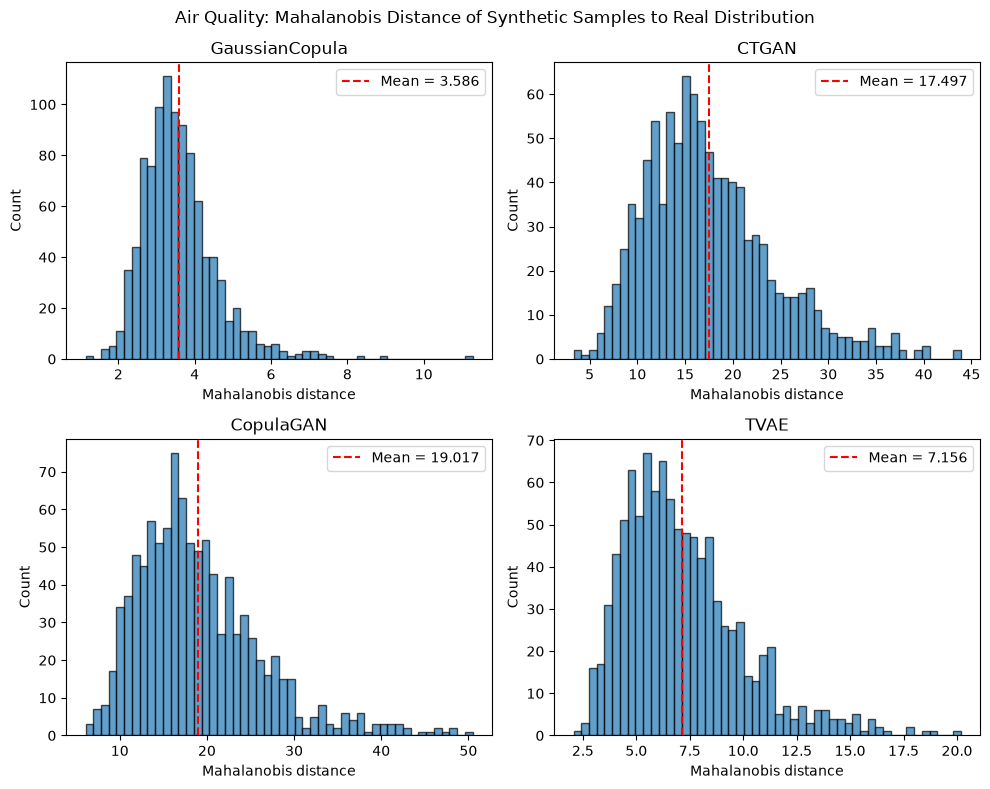

In [62]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Air Quality: Mahalanobis Distance of Synthetic Samples to Real Distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
fig_dir = os.path.join(ROOT, "figures")
os.makedirs(fig_dir, exist_ok=True)

plt.savefig(
    os.path.join(fig_dir, "mahalanobis_airquality_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [63]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

hungarian_results = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "CO(GT)"]

real_matrix = data[num_cols].to_numpy(dtype=np.float64)
n_samples = len(real_matrix)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=np.float64)
    assert synth_numeric.shape[0] == n_samples, (
        f"Synthetic size {synth_numeric.shape[0]} != real size {n_samples}"
    )

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "matched_distances": matched_distances,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_distance_per_match"],
            r["median_distance_per_match"],
            r["std_distance_per_match"],
            r["max_distance_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_distance_per_match",
        "median_distance_per_match",
        "std_distance_per_match",
        "max_distance_per_match",
    ],
).T

hungarian_summary.index.name = "Model"
hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

print("Hungarian matching using Mahalanobis distance (lower is better):")
display(hungarian_summary)


Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
GaussianCopula,18.531944,14.142054,20.518284,236.336539
TVAE,20.605003,16.213280,19.757011,245.303901
CopulaGAN,42.251758,32.093494,38.984031,341.597898
CTGAN,145.425833,51.132501,273.438784,1631.648555


In [64]:
import numpy as np
import pandas as pd

def greedy_one_to_one_matching_fast(D):
    n_rows, n_cols = D.shape
    n_match = min(n_rows, n_cols)

    used_rows = np.zeros(n_rows, dtype=bool)
    used_cols = np.zeros(n_cols, dtype=bool)

    flat_order = np.argsort(D, axis=None)
    pairs = []

    for idx in flat_order:
        i = idx // n_cols
        j = idx % n_cols
        if not used_rows[i] and not used_cols[j]:
            used_rows[i] = True
            used_cols[j] = True
            pairs.append((i, j, float(D[i, j])))
            if len(pairs) == n_match:
                break

    distances = np.array([p[2] for p in pairs], dtype=np.float64)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

greedy_results = {}
comparison_rows = []

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "CO(GT)"]

X_real_full = data[num_cols].to_numpy(dtype=np.float64)

MAX_ROWS = 2000
rng = np.random.default_rng(42)

if len(X_real_full) > MAX_ROWS:
    real_idx = rng.choice(len(X_real_full), size=MAX_ROWS, replace=False)
else:
    real_idx = np.arange(len(X_real_full))

X_real = X_real_full[real_idx]

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    X_synth_full = synthetic_data[name][num_cols].to_numpy(dtype=np.float64)

    if len(X_synth_full) > MAX_ROWS:
        synth_idx = rng.choice(len(X_synth_full), size=MAX_ROWS, replace=False)
    else:
        synth_idx = np.arange(len(X_synth_full))

    X_synth = X_synth_full[synth_idx]

    D = pairwise_mahalanobis(X_real, X_synth, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    total_g, mean_g, _ = greedy_one_to_one_matching_fast(D)

    greedy_results[name] = {
        "total_distance": total_g,
        "mean_distance": mean_g
    }

    h_total = hungarian_results[name]["total_distance"]
    h_mean = hungarian_results[name]["mean_distance_per_match"]

    comparison_rows.append({
        "Model": name,
        "Rows_Used_For_Greedy": int(min(len(X_real), len(X_synth))),
        "Greedy total (sampled)": total_g,
        "Hungarian total (full)": h_total,
        "Greedy mean (sampled)": mean_g,
        "Hungarian mean (full)": h_mean,
        "Total diff": total_g - h_total,
        "Mean diff": mean_g - h_mean,
    })

greedy_summary = pd.DataFrame({
    name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
    for name in greedy_results
}, index=["total_distance", "mean_distance"]).T
greedy_summary.index.name = "Model"

print("Greedy one-to-one matching (fast sampled version):")
display(greedy_summary)

print("\nComparison table:")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)


Greedy one-to-one matching (fast sampled version):


,total_distance,mean_distance
Model,,
GaussianCopula,2.873888e+04,2.873888e+01
CTGAN,3.000028e+10,3.000028e+07
CopulaGAN,3.800001e+11,3.800001e+08
TVAE,5.342266e+04,5.342266e+01



Comparison table:


,Rows_Used_For_Greedy,Greedy total (sampled),Hungarian total (full),Greedy mean (sampled),Hungarian mean (full),Total diff,Mean diff
Model,,,,,,,
GaussianCopula,1000,2.873888e+04,18531.943612,2.873888e+01,18.531944,1.020694e+04,1.020694e+01
CTGAN,1000,3.000028e+10,145425.833107,3.000028e+07,145.425833,3.000014e+10,3.000014e+07
CopulaGAN,1000,3.800001e+11,42251.757913,3.800001e+08,42.251758,3.800001e+11,3.800001e+08
TVAE,1000,5.342266e+04,20605.002842,5.342266e+01,20.605003,3.281766e+04,3.281766e+01


In [65]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "CO(GT)"]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")


Using numeric non-target features: 12
GaussianCopula: avg matched Mahalanobis distance = 2.4049
CTGAN: avg matched Mahalanobis distance = 15.5821
CopulaGAN: avg matched Mahalanobis distance = 16.7797
TVAE: avg matched Mahalanobis distance = 5.4131


In [66]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "CO(GT)"]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")


Using numeric non-target features: 12
GaussianCopula: avg matched Mahalanobis distance = 2.4049
CTGAN: avg matched Mahalanobis distance = 15.5821
CopulaGAN: avg matched Mahalanobis distance = 16.7797
TVAE: avg matched Mahalanobis distance = 5.4131


In [67]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "CO(GT)"]

real_df = data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=np.float64)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=np.float64)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

    print(f"\n{model_name} - Hungarian mappings for R1 to R20:")
    for r in range(20):
        if r in r_to_match:
            s, dist = r_to_match[r]
            print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
        else:
            print(f"R{r+1} -> No match found")



CTGAN - Hungarian mappings for R1 to R20:
R1 -> S464   distance = 8.9852
R2 -> S746   distance = 22.0724
R3 -> S578   distance = 12.9608
R4 -> S379   distance = 23.6157
R5 -> S509   distance = 15.8083
R6 -> S834   distance = 16.6446
R7 -> S857   distance = 22.1118
R8 -> S183   distance = 14.8718
R9 -> S87   distance = 30.0018
R10 -> S933   distance = 7.2820
R11 -> S117   distance = 8.2028
R12 -> S689   distance = 16.4123
R13 -> S892   distance = 18.8072
R14 -> S861   distance = 15.7790
R15 -> S563   distance = 12.0591
R16 -> S918   distance = 13.6406
R17 -> S201   distance = 26.1951
R18 -> S852   distance = 7.5427
R19 -> S830   distance = 18.4121
R20 -> S446   distance = 20.3124

CopulaGAN - Hungarian mappings for R1 to R20:
R1 -> S233   distance = 10.3854
R2 -> S217   distance = 14.0943
R3 -> S265   distance = 11.1970
R4 -> S226   distance = 15.1498
R5 -> S654   distance = 22.1088
R6 -> S625   distance = 14.4718
R7 -> S555   distance = 17.8680
R8 -> S474   distance = 8.8111
R9 -> S51

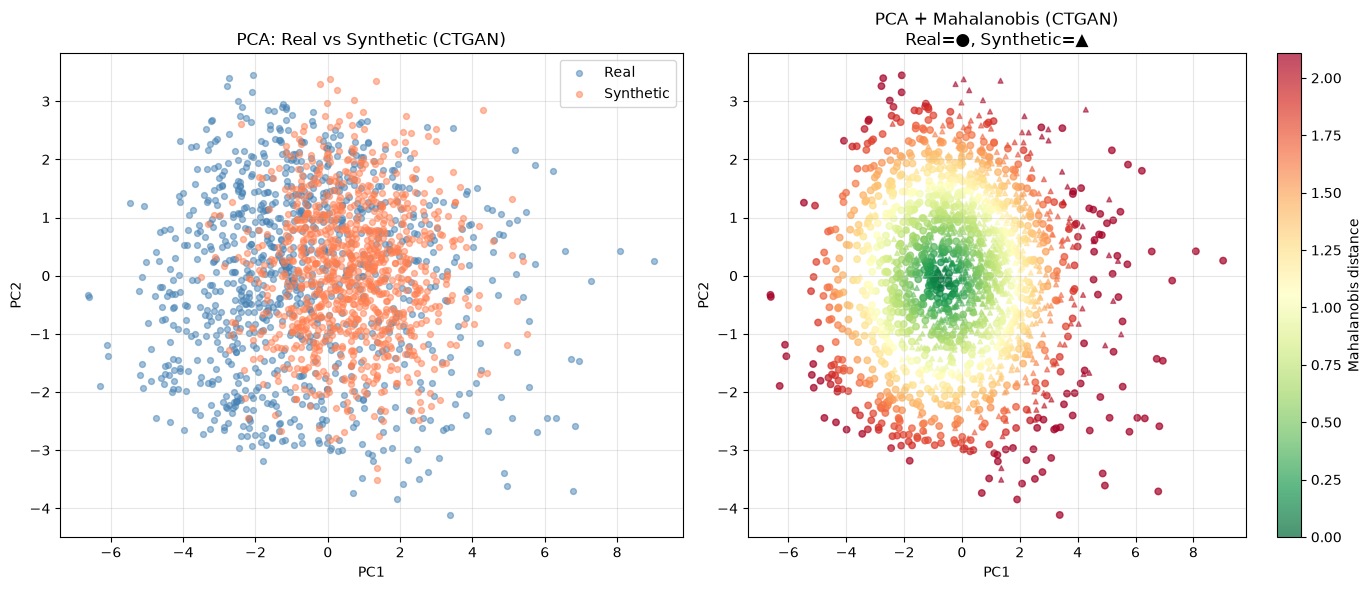

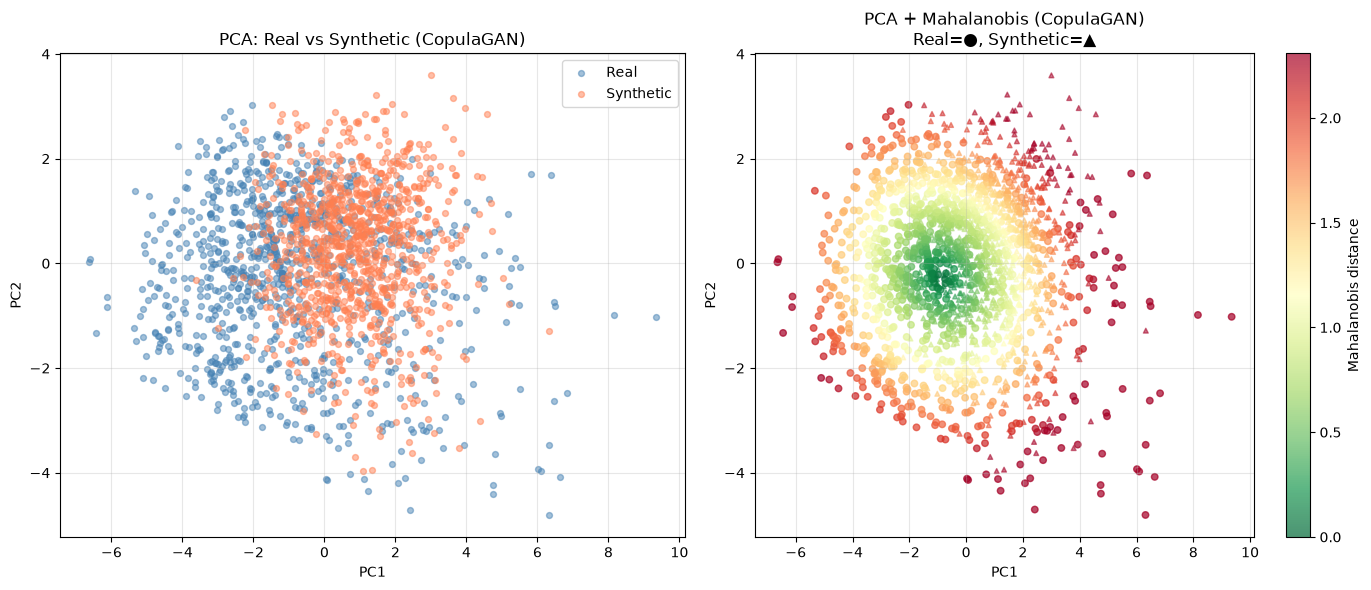

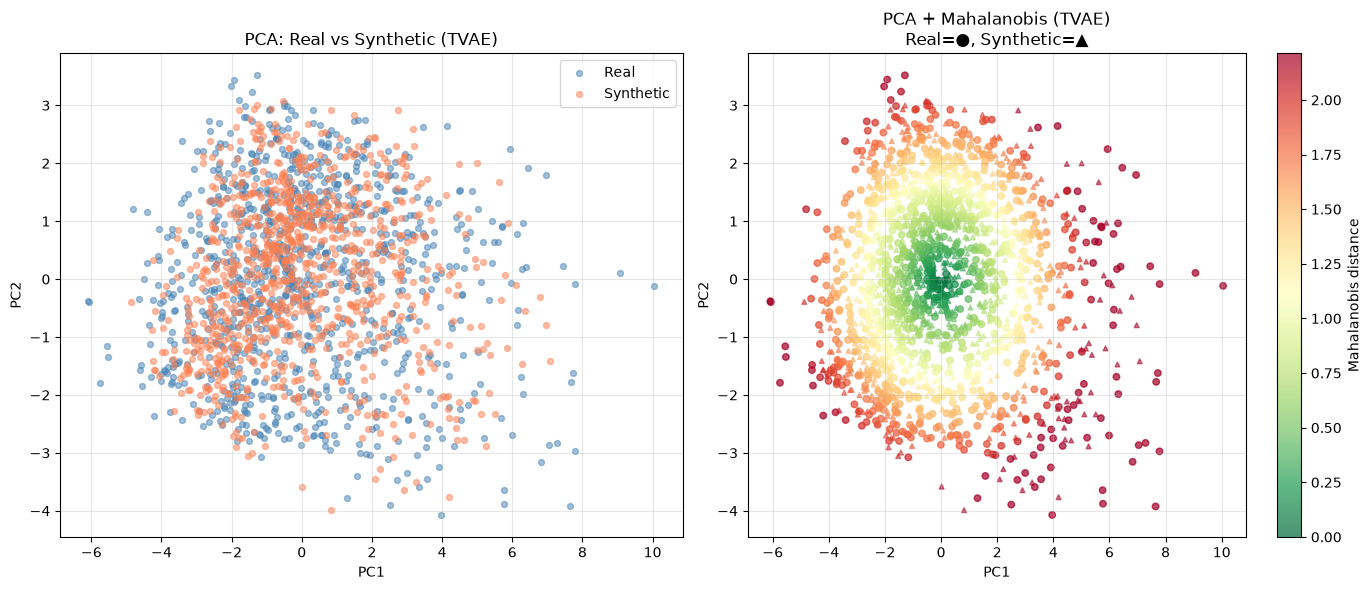

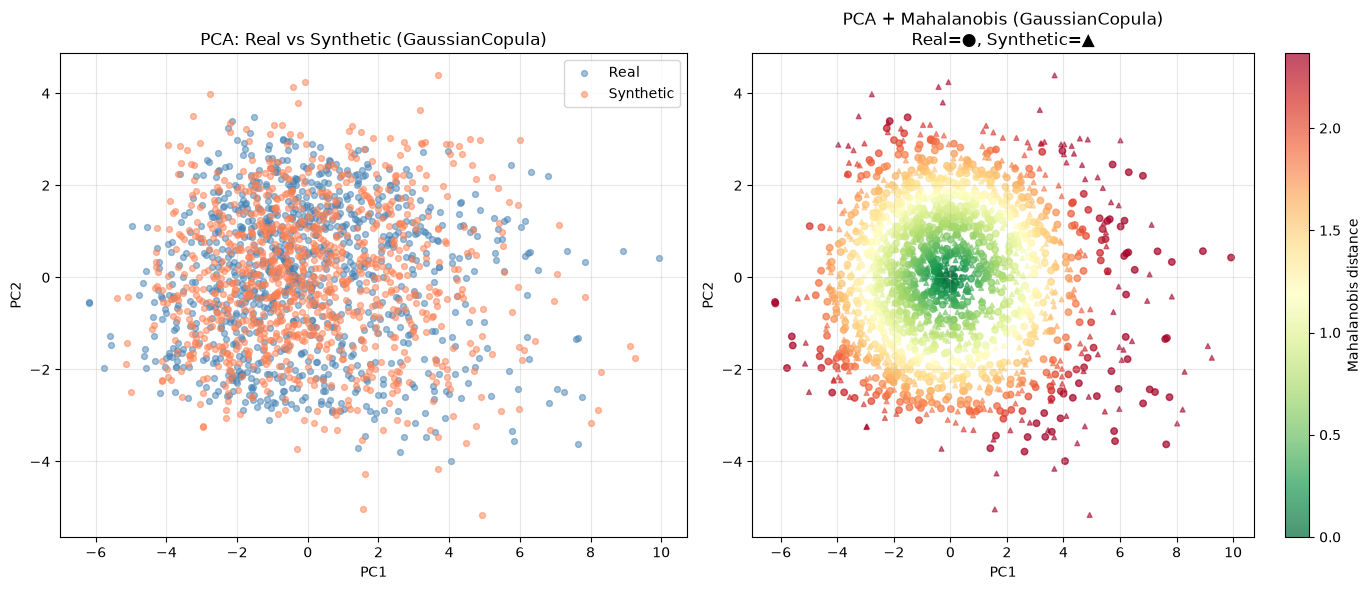

,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
0,CTGAN,1.268418,0.983945,-0.284472
2,TVAE,1.267111,1.117069,-0.150042
1,CopulaGAN,1.258236,1.209952,-0.048284
3,GaussianCopula,1.266211,1.237823,-0.028388


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "CO(GT)"]

X_r = real_df[feature_cols].to_numpy(dtype=np.float64)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"{model_name} not found in synthetic_data, skipping.")
        continue

    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=np.float64)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = np.linalg.pinv(cov_z + reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
display(summary_df)


## Air Quality — Excel export

Output file: **`Hungarian_Mahalanobis_Four_Models_AirQuality.xlsx`**


In [ ]:
# AIR QUALITY EXPORT (not Air Quality)
import pandas as pd
import numpy as np

DATASET_NAME = "AirQuality"
EXCEL_FILENAME = "Hungarian_Mahalanobis_Four_Models_AirQuality.xlsx"
print("Dataset:", DATASET_NAME)
print("Writing Excel file:", EXCEL_FILENAME)

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = EXCEL_FILENAME,
):
    dataset_name = DATASET_NAME
    model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                continue

            synth_df = synthetic_data[model_name].copy()
            _common = [c for c in real_df.columns if c in synth_df.columns]
            synth_df = synth_df[_common]

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "selected_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["selected_distances"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                raise KeyError(f"No distance array found for {model_name}")

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = f"{dataset_name}_{model_name}"[:31]
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)

            summary_rows.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name=f"{dataset_name}_Summary", index=False)

    print(f"Excel file created: {filename}")


real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "CO(GT)"]

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synthetic_data,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename=EXCEL_FILENAME,
)


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [70]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample_regression(model, X, y):
    y_pred = model.predict(X)
    return (y - y_pred) ** 2

def privacy_metrics_mia_regression(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample_regression(model, X_train_s, y_train)
    loss_test = model_loss_per_sample_regression(model, X_test_s, y_test)

    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

target_col = "CO(GT)"
feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

real_df = data.copy()
synth_df = synthetic_data["GaussianCopula"][real_df.columns].copy()

X_train = real_df[feature_cols].to_numpy(dtype=np.float64)
y_train = real_df[target_col].to_numpy(dtype=np.float64)

X_test = synth_df[feature_cols].to_numpy(dtype=np.float64)
y_test = synth_df[target_col].to_numpy(dtype=np.float64)

model = Ridge(alpha=1.0, random_state=42)
metrics = privacy_metrics_mia_regression(model, X_train, y_train, X_test, y_test)
print(metrics)

{'AUC': 0.6008610000000001, 'Advantage': 0.17400000000000004, 'TPR_at_FPR_001': 0.01}


In [71]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "CO(GT)"]
X_train = data[feature_cols].to_numpy(dtype=np.float64)

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

for model_name in model_order:
    X_test = synthetic_data[model_name][feature_cols].to_numpy(dtype=np.float64)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

comparison_df = pd.DataFrame(rows)[
    ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
].sort_values("AUC", ascending=False).reset_index(drop=True)

print("MIA (Mahalanobis) comparison across 4 synthetic models:")
display(comparison_df)


MIA (Mahalanobis) comparison across 4 synthetic models:


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,CopulaGAN,0.999291,0.976,0.985,3.233344,18.362268
1,CTGAN,0.997577,0.964,0.972,3.233344,17.162783
2,TVAE,0.934148,0.741,0.446,3.233344,6.964417
3,GaussianCopula,0.587864,0.168,0.049,3.233344,3.375032
